---
### Watermarking LLMs: reproduction and extensions
---

---
##### Imports

In [1]:
import json
import os

import numpy as np
import pandas as pd
import torch
from IPython.display import Image, Markdown, display
from transformers import AutoTokenizer

import core as C
import params as P
import plots as PL
import stats as S

---
##### Setup
Raw rows come from `results/raw/` (gzipped JSON lines); every table below is also written to `results/summary/`.

In [2]:
pd.set_option("display.width", 200, "display.max_columns", 40, "display.precision", 3)
os.makedirs(C.SUMMARY, exist_ok=True)
V = {k: C.vocab_size(AutoTokenizer.from_pretrained(P.MODELS[k])) for k in ("opt", "qwen")}
V["qwen-it"] = V["qwen"]
VO = V["opt"]
CFG = {}
for _, cfgs in P.EXPERIMENTS.values():
    for c in cfgs:
        if c["id"] not in CFG or c["n"] > CFG[c["id"]]["n"]:
            CFG[c["id"]] = c


def have(cid):
    return os.path.exists(C.gen_path(cid))


def gen(cid, n=None):
    """Kept rows (T = 200 +- 5) of a paper-reproduction config, else all rows with T > 0; first n."""
    c = CFG.get(cid, {})
    rows = C.load_gen(cid, kept=c.get("keep", False))
    rows = [r for r in rows if r["T"] > 0]
    return rows[:n or c.get("n")]


def save(name, df):
    df.to_csv(os.path.join(C.SUMMARY, name + ".csv"), index=False)
    with open(os.path.join(C.SUMMARY, name + ".md"), "w") as f:
        f.write(df.to_markdown(index=False, floatfmt=".3f") + "\n")
    return df


def show(*names):
    """Display saved figures from figures/ (those that exist)."""
    for n in names:
        p = os.path.join("figures", n)
        if os.path.exists(p):
            display(Image(filename=p))


def save_json(name, obj):
    with open(os.path.join(C.SUMMARY, name + ".json"), "w") as f:
        json.dump(obj, f, indent=1, default=float)


human = [r for r in C.load_rows(C.raw_path("human", "c4")) if r["idx"] < P.N_GEN_PROMPTS]
hz = {g: np.array([S.z_ranks(r["ranks"], g, VO) for r in human]) for g in P.GAMMAS}
d0 = gen("opt-news-m-d0") if have("opt-news-m-d0") else []
d0z = {g: np.array([S.z_ranks(r["ranks"], g, VO) for r in d0]) for g in P.GAMMAS}
calib = pd.DataFrame([dict(negatives=name, gamma=g, n=len(z[g]), z_mean=z[g].mean(), z_sd=z[g].std(),
                           FPR_z4=(z[g] > 4).mean())
                      for name, z in (("human baselines", hz), ("delta = 0 generations", d0z)) for g in P.GAMMAS])
save("calibration_negatives", calib)


def z_under_key(texts, key, gamma=0.5):
    """z (repeats counted) of (ids, prev0) texts with green lists rebuilt under another hash key."""
    ranks = {}
    for ids, prev0 in texts:
        for p in [prev0] + list(ids[:-1]):
            if p not in ranks:
                perm = torch.randperm(VO, generator=torch.Generator().manual_seed(key * int(p))).numpy()
                ranks[p] = np.empty(VO, dtype=np.int32)
                ranks[p][perm] = np.arange(VO, dtype=np.int32)
    k = int(gamma * VO)
    return [S.z_of([int(t < VO and ranks[p][t] < k) for p, t in zip([prev0] + list(ids[:-1]), ids)], gamma)
            for ids, prev0 in texts]


# null calibration under 6 hash keys (delta = 0 generations of the first 500 prompts, 1,000 human baselines)
last = {r["idx"]: r["prompt_ids"][-1] for r in C.read_jsonl(C.PROMPTS_FILE)}
d0_500 = [(r["ids"], last[r["idx"]]) for r in C.read_jsonl(C.gen_path("opt-news-m-d0")) if r["idx"] < 500 and r["T"] >= 195]
hum_1000 = [(r["ids"], last[r["idx"]]) for r in human]
null_keys = []
for key in [P.HASH_KEY, 15485867, 32452843, 49979687, 67867967, 86028121]:
    zd, zh = z_under_key(d0_500, key), z_under_key(hum_1000, key)
    null_keys.append([key, round(np.mean(zd), 3), round(np.std(zd), 3), round(np.mean(zh), 3), round(np.std(zh), 3)])
with open(os.path.join(C.SUMMARY, "null_mean_by_key.json"), "w") as f:
    json.dump(null_keys, f)
display(pd.DataFrame(null_keys, columns=["hash key", "delta=0 z mean", "delta=0 z sd", "human z mean", "human z sd"]))

,hash key,delta=0 z mean,delta=0 z sd,human z mean,human z sd
0,15485863,-0.342,1.302,-0.197,1.043
1,15485867,0.112,1.363,0.081,1.117
2,32452843,0.709,1.196,0.554,1.078
3,49979687,-0.123,1.237,-0.243,1.066
4,67867967,-0.521,1.282,-0.362,1.095
5,86028121,-0.211,1.305,-0.155,1.030


---
##### Headline (§4.1)
γ = 0.5, δ = 2, multinomial, T = 200 ± 5; Theorem 4.2 evaluated with our own spike entropy.

In [3]:
cid, g, d, T = "opt-news-m-d2-g0.5", 0.5, 2.0, 200
rows = gen(cid)
all_rows = [r for r in C.load_gen(cid) if r["idx"] <= rows[-1]["idx"]]
s_seq = np.array([np.mean(r["S_paper"]) for r in rows])
s_samp = np.array([np.mean(r["S_sampled"]) for r in rows])
z = np.array([r["z"] for r in rows])
counts = np.array([np.sum(r["green"]) * T / r["T"] for r in rows])     # green count scaled to T = 200
b = S.thm42(s_seq.mean(), g, d, T)
b_corr = S.thm42(s_samp.mean(), g, d / P.TEMP, T)
q25 = np.percentile(s_seq, 25)
beam4 = gen("opt-news-beam4-d2-g0.5") if have("opt-news-beam4-d2-g0.5") else []
head = pd.DataFrame([
    ("generations kept (T in 195..205)", 507, len(rows)),
    ("generated (dropped by the T filter)", None, f"{len(all_rows)} ({len(all_rows) - len(rows)})"),
    ("average spike entropy S", 0.807, s_seq.mean()),
    ("Thm 4.2 lower bound on E|s|_G", 142.2, b["mean"]),
    ("observed mean green count", 159.5, counts.mean()),
    ("Thm 4.2 upper bound on sd", 6.41, b["sd"]),
    ("observed sd of green count", None, counts.std()),
    ("predicted detection at z = 4 (Gaussian, from the bounds)", 0.986, S.predicted_detection(b["mean"], b["sd"], g, T)),
    ("observed TPR at z = 4", 0.984, (z > 4).mean()),
    ("observed TPR at z = 4, 4-way beam search", 0.996, np.mean([r["z"] > 4 for r in beam4]) if beam4 else None),
    ("4-beam count", None, len(beam4)),
    ("TPR at z = 4 above the 25th entropy percentile", 1.000, (z[s_seq >= q25] > 4).mean()),
    ("sequences above the 25th percentile", 375, int((s_seq >= q25).sum())),
    ("FPR at z = 4 on human baselines", 0.0, (hz[0.5] > 4).mean()),
    ("mean z drop after decode -> re-encode", None, np.mean([r["z"] - r["z_reenc"] for r in rows])),
    ("z ignoring repeated (context, token) pairs: TPR at z = 4", None, np.mean([r["z_norep"] > 4 for r in rows])),
    ("Ext 1a: corrected bound (S_sampled, alpha = e^(delta/tau)) on E|s|_G", None, b_corr["mean"]),
    ("Ext 1a: average S_sampled", None, s_samp.mean()),
    ("Gaussian formula applied to the paper's own bounds (142.2, 6.41)", 0.986, S.predicted_detection(142.2, 6.41, 0.5, 200)),
], columns=["quantity", "paper", "ours"])
head["ours"] = [x if isinstance(x, str) or x is None else round(float(x), 4) for x in head["ours"]]
def ci_str(c, d=3):
    return f"[{c[0]:.{d}f}, {c[1]:.{d}f}]"
sem = counts.std(ddof=1) / np.sqrt(len(counts))
hi_s = s_seq >= q25
ci = {"observed mean green count": ci_str((counts.mean() - 1.96 * sem, counts.mean() + 1.96 * sem), 1),
      "observed TPR at z = 4": ci_str(S.wilson_of(z > 4)),
      "observed TPR at z = 4, 4-way beam search": ci_str(S.wilson_of([r["z"] > 4 for r in beam4])) if beam4 else None,
      "TPR at z = 4 above the 25th entropy percentile": ci_str(S.wilson_of(z[hi_s] > 4)),
      "FPR at z = 4 on human baselines": ci_str(S.wilson_of(hz[0.5] > 4)),
      "generated (dropped by the T filter)": "kept share " + S.fmt_ci(len(rows) / len(all_rows), S.wilson(len(rows), len(all_rows))),
      "z ignoring repeated (context, token) pairs: TPR at z = 4": ci_str(S.wilson_of([r["z_norep"] > 4 for r in rows]))}
head["ours_95ci"] = head.quantity.map(ci)
check = S.predicted_detection(142.2, 6.41, 0.5, 200)
print(f"Gaussian formula applied to the paper's own bounds gives {check:.4f} (paper reports 0.986)")
save("headline", head.astype({"ours": object}))
display(head)
PL.z_hist({"watermarked (δ=2)": z, "no watermark (δ=0)": d0z[0.5], "human": hz[0.5]}, "head_z_hist.png",
          "Headline: z-scores, γ = 0.5, δ = 2, T = 200")

Gaussian formula applied to the paper's own bounds gives 0.9850 (paper reports 0.986)


,quantity,paper,ours,ours_95ci
0,generations kept (T in 195..205),507.000,497.0,NaN
1,generated (dropped by the T filter),NaN,998 (501),"kept share 0.498 [0.467, 0.529]"
2,average spike entropy S,0.807,0.813,NaN
3,Thm 4.2 lower bound on E|s|_G,142.200,143.205,NaN
4,observed mean green count,159.500,158.339,"[157.5, 159.2]"
5,Thm 4.2 upper bound on sd,6.410,6.377,NaN
6,observed sd of green count,NaN,9.855,NaN
7,"predicted detection at z = 4 (Gaussian, from t...",0.986,0.99,NaN
8,observed TPR at z = 4,0.984,0.986,"[0.971, 0.993]"
9,"observed TPR at z = 4, 4-way beam search",0.996,1.0,"[0.975, 1.000]"


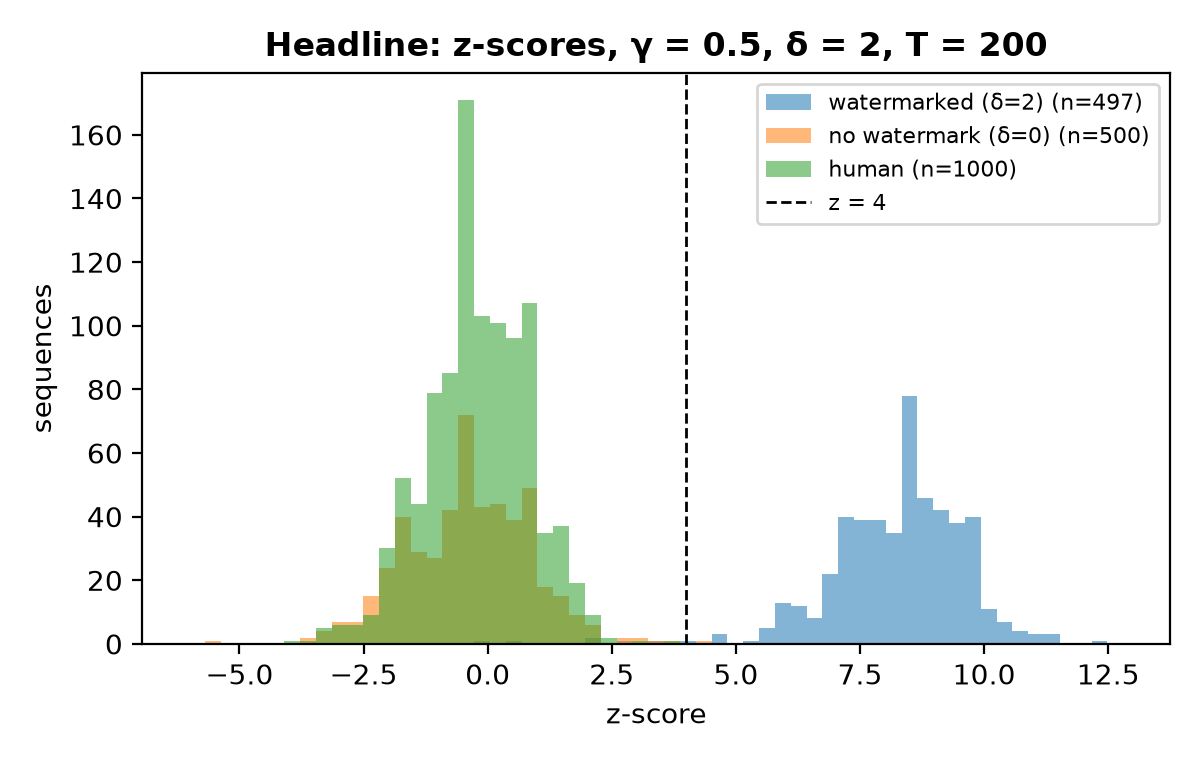

In [4]:
show("head_z_hist.png")

In [5]:
# Tables 3-6 style: 5 highest- and 5 lowest-entropy generations
ppl = {r["idx"]: r["ppl"] for r in rows}
nowm = {r["idx"]: r for r in C.load_gen("opt-news-m-d0")}
prompts = {r["idx"]: r for r in C.read_jsonl(C.PROMPTS_FILE)}
hum = {r["idx"]: r for r in human}


def clip(t, n=45):
    w = t.replace("|", "/").replace("\n", " ").split()
    return " ".join(w[:n]) + (" ..." if len(w) > n else "")


ex = []
order = np.argsort(-s_seq)
for tag, ids in (("high", order[:5]), ("low", order[-5:])):
    for i in ids:
        r = rows[i]
        ex.append(dict(entropy=tag, idx=r["idx"], prompt_tail="... " + " ".join(prompts[r["idx"]]["prompt_text"].split()[-25:]).replace("|", "/"),
                       human=clip(hum[r["idx"]]["text"]), no_watermark=clip(nowm[r["idx"]]["text"]) if r["idx"] in nowm else "",
                       watermarked=clip(r["text"]), S=s_seq[i], z=r["z"], PPL=ppl[r["idx"]]))
ex = pd.DataFrame(ex)
save("examples", ex)
display(Markdown(ex.to_markdown(index=False, floatfmt=".2f")))

| entropy   |   idx | prompt_tail                                                                                                                                                                                               | human                                                                                                                                                                                                                                                                                                                                    | no_watermark                                                                                                                                                                                                                                                                                                                             | watermarked                                                                                                                                                                                                                                                                                                               |    S |     z |   PPL |
|:----------|------:|:----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|:--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-----:|------:|------:|
| high      |   691 | ... open to make the most of the weather too. Enjoy the long days and the peace ...school holidays will be here before you know it!                                                                       | Ice cream is so easy if you follow this simple rule ... double cream only. That way it sets perfectly, no mixing or machines required. It’s really rich but tastes amazing. Place the double cream, egg yolks and sugar in a pan. Heat, gently, stirring ...                                                                             | So, here's a recipe for a simple ice cream that can be made at home and serves two people. This is a great recipe for kids too. It's so simple to make too. I like using cream, we have plenty of it around here and ...                                                                                                                 | I can't wait to hear from you with recipes and photos for any of these wonderful weekends you've got ahead of us. If you've got any tips for me or other food bloggers I'll be greatful for any help, even if it means putting a ...                                                                                      | 0.89 |  8.91 | 13.77 |
| high      |   594 | ... is formulated so elegantly it's reminiscent of the kind of disciplined artistry found in works like 'Day on Earth' by Doris Humphrey and Jose Limon's                                                 | 'There is a Time' through which the choreographers clear voice can be seen. That's honesty we experienced in this work. The evening concluded with an excerpt from 'Dancrcollageforromie' choreographed by Garth Fagan in 2003. The costumes and use of minimal props set a jovial tone ...                                              | 'The Dance of the Vibration'. In the end we find ourselves at a crossroads; and once again we find ourselves at the mercy of the hands of a master, one who knows how to practically manipulate space. The dance was a testament to the power ...                                                                                        | 'The Truth' from the 1980s and 1990s. It's a bit jarring to hear the choreographer say "we are both in a state of flux" but it must be said, the movement and sound is so beautifully harmonized that the dissonance is almost negligible as they ...                                                                     | 0.88 |  8.49 | 11.98 |
| high      |   699 | ... the edge of the disk could then have helped the navigator determine north-south. While similar modern devices do work successfully (as seen in the NOVA                                               | program "The Vikings"), many have questioned if the Greenland disc was actually used in this way. It is less than three inches across and the markings around the perimeter are so crudely carved as to make the interpretation doubtful. When at length they were all ...                                                               | satellite navigation system), they are not precise enough for true north or south. The sunstone hypothesis may be more plausible. Its use may have been a convenience, but its utility undoubtedly helped Viking sailors find their way around the world. The discovery of Viking ships ...                                              | series of weather forecasts, or in the GPS unit of the iPod) the disks used in the sagas were not equipped with a bearing system or with a complete circle, much less a complete star-track. Any attempt to measure a position using a sunstone would ...                                                                 | 0.88 |  9.62 | 13.89 |
| high      |   152 | ... air-permeable outer shell with a new Polartec Alpha Direct insulation, Outdoor Research's new Ascendant line attempts to create a jacket that's puffy, softshell, and windshell                       | . The insulated jacket breathes and remains supremely lightweight, and the insulation includes lofted knit fibers that prevent fiber migration for a uniform consistency, while remaining water repellent and breathable. The stability of the design allows the technology to pair with a wider variety of ...                          | all in one. Featuring a breathable, stretchy shell and a breathable, stretchy insulation, the jacket offers the same warmth retention as the core insulation, but with more volume. The outer shell is constructed with a brushed-nylon fabric that's flexible, providing a softshell feel and the ...                                   | . The 3D knit, which features open pockets and extra ventilation openings, is designed to mimic the weave found in down, making it lighter and more durable than down while retaining the loft. The first thing you'll notice is the insulation is much lighter weight, ...                                               | 0.87 |  9.62 | 12.48 |
| high      |   510 | ... secondary authentication codes and passwords as well. Successfully doing so means attackers can execute automated transactions against the users financial accounts. Given that 73% of                | users are unable to distinguish between real and fake popup messages (Sharek, et al 2008, "Failure to Recognize Fake Internet Popup Warning Messages") the potential for Neverquest and similar Trojans to succeed in such efforts is more likely than not, particularly when those popups are ...                                       | financial institutions have reported attacks on their systems from Neverquest and related Trojans, it's clear that this attack vector is a major concern. And while attackers are increasingly targeting mobile devices, it's critical that financial institutions implement layered authentication to protect their users. The good ... | global consumers use their smartphones as their primary payment device and 30% have their mobile device PIN number saved in a bank account, the potential financial damage here is quite real. The average financial institution uses 10 million cards a month, making it an attractive ...                               | 0.87 | 11.46 | 12.82 |
| low       |   425 | ... to match the national demographics of gender, age, race, Hispanic ethnicity, education, region, population density, and phone status (cellphone only/landline only/both, cellphone mostly, and having | an unlisted landline number). Demographic weighting targets are based on the March 2012 Current Population Survey figures for the aged 18 and older U.S. population. Phone status targets are based on the July-December 2011 National Health Interview Survey. Population density targets are based on the ...                          | an available cell phone). For complete details on sampling and weighting methodology, please visit the Gallup Daily tracking page. The margin of sampling error is greater among subgroups. Visit the Gallup Daily tracking page for the latest trends in U.S. public opinion.                                                           | an internet-connected phone but no internet connection). Demographic weighting factors used in Gallup Daily tracking polls are available here. All reported margins of sampling error include the computed design effects for weighting and sample design. For results based on the total sample of black respondents ... | 0.66 |  3.96 |  2.14 |
| low       |   295 | ... the City of Viroqua in Conjunction with EDA Grant, Designation of Vernon County Snowmobile Trail Coordinator, Outdoor Recreation Aids, Repeal of Vernon County, Wisconsin Code                        | of Ordinances ch. art. I, §2-63 (2016) and Amendment to County Board Rules regarding Public Bidding for Purchases Exceeding $25,000, Budget 2019, Additional Funds to Cover State Mental Health Institution Costs, Notice of Disallowance of Claim, Ordinances, Remonstrance, Reports of Standing Committees, Adjournment. The Solid ... | Section 4-14.002, Legislative Session, State of Wisconsin Budget, Public Notice, Public Comment, Set next meeting date. County Board of Supervisors meets at 9:30 a.m. on April 16, 2019 in the County Board Room Courthouse Annex. County Board of Supervisors meets at 9:30 a.m. on April ...                                          | Section 4-1.002, Legislative Session, County Board of Supervisors meeting May 8, 2018, Board of Supervisors meeting May 8, 2018, Board of Supervisors meeting May 9, 2018, Board of Supervisors meeting May 9, 2018, County Board of Supervisors meeting May 9, 2018, County Board of Supervisors ...                     | 0.65 |  8.91 |  1.51 |
| low       |   528 | ... take to reach फाजिल्का Railway Station? फिरोजपुर कैंट फाजिल्का डी एम यू reach on day 1 to फाजिल्का Railway Station. The arrival time of फिरो                                                                    | जपुर कैंट फाजिल्का डी एम यू at फाजिल्का Railway Station is 10:45. फिरोजपुर कैंट फाजिल्का डी एम यू covers 88 km to reach फाजिल्का Railway Station at average speed of 43 km/hr. फिरोजपुर कैंट फाजिल्का डी एम यू passes through 14 stations.                                                                                                                     | जपुर कैंट फाजिल्का डी एम यू की तरह की लगाने की लगाई तो बल्किंग्रील की लगाई तो बल्किंग्रील की लगाई तो बल्किंग्रील की लगाई तो बल्क�                                                                                                                                                                                                                               | जपुर कैंट फाजिल्का डी एम यू अपनी सियासपुर (74971) is 08:41. The average arrival time of फिरोजपुर कैंट फाजिल्का डी एम यू सियासपुर (74971) is 08:41. The earliest departure time of फिरोजपुर कैंट फाजिल्का ड                                                                                                                                   | 0.62 | -0.14 |  1.48 |
| low       |   480 | ... most happy when they're cutting hair, so at a Great Clips salon, that's exactly what you get to ... 4 DAYS AGO Do you match?                                                                          | 04/19/2019 22:56:19 95676326 24 3 0 3735 1 1 Personal Care Personal Appearance Hair Stylist Hair Stylist Full Time Great Clips, Inc. / San Marcos, TX 4 DAYS AGO Stylist At Great Clips, we know that stylists like you are most happy when they're cutting ...                                                                          | 04/18/2019 16:00:22 96834456 24 0 0 3634 1 1 Personal Care Personal Appearance Salon Manager - Private Salon Salon Manager - Private Salon Full Time Team Member at Ria Beauty Salon / Austin, TX Ria Beauty Salon is looking for a person who is ready ...                                                                              | 04/18/2019 16:38:25 95687555 24 0 0 3634 1 1 Personal Care Personal Appearance Hair Stylist Hair Stylist Full Time Great Clips, Inc. / Austin, TX 4 DAYS AGO Stylist At Great Clips, we know that stylists like you are most happy when they're cutting hair, ...                                                         | 0.62 |  2.26 |  1.52 |
| low       |   562 | ... Aaron Scales said council had received the planning permit and would be advertising the plans in coming days. He said the construction phase would create                                             | jobs in the region. “We’re very supportive of the announcement, it's a fantastic facility to have in Tallangatta,” Cr Scales said. Once open, 24 existing DELWP staff, 15 forest and fire officers and project fire fighters will transfer to the facility, as well as staff ...                                                         | jobs in the region. “We’re very supportive of the announcement, it’s a fantastic facility to have in Tallangatta,” Cr Scales said. Once open, 24 existing DELWP staff, 15 forest and fire officers and project fire fighters will transfer to the facility, as well as staff ...                                                         | jobs in the region. “We’re very supportive of the announcement, it’s a fantastic facility to have in Tallangatta,” Cr Scales said. Once open, 24 existing DELWP staff, 15 forest and fire officers and project fire fighters will transfer to the facility, as well as staff ...                                          | 0.57 |  0.57 |  1.06 |

In [6]:
# generated vs kept (T = 200 +- 5) for every multinomial news config: the watermark shortens outputs
kc = []
for cid, c in sorted(CFG.items()):
    if c.get("keep") and have(cid):
        rows_all = C.load_gen(cid)
        k = sum(P.T_KEEP[0] <= r["T"] <= P.T_KEEP[1] for r in rows_all)
        e50 = [r["T"] < 50 for r in rows_all]
        kc.append(dict(config=cid, gamma=c["gamma"], delta=c["delta"], generated=len(rows_all), kept=k, kept_share=k / len(rows_all),
                       kept_lo=S.wilson(k, len(rows_all))[0], kept_hi=S.wilson(k, len(rows_all))[1],
                       ended_before_50=np.mean(e50), ended_lo=S.wilson_of(e50)[0], ended_hi=S.wilson_of(e50)[1]))
kc = save("kept_counts", pd.DataFrame(kc))
display(kc)
# delta = 0 generations above z = 4 (with repeats), with z ignoring repeated (context, token) pairs
fp = [dict(idx=r["idx"], gamma=g, z=S.z_ranks(r["ranks"], g, VO), z_norep=S.z_norep(r["ranks"], r["ids"], g, VO),
           unique_pairs=int(S.first_occurrence(r["ids"]).sum()), text=r["text"][:200].replace(chr(10), " "))
      for g in P.GAMMAS for r in d0 if S.z_ranks(r["ranks"], g, VO) > 4]
save("delta0_false_positives", pd.DataFrame(fp))

# why the watermark changes length: green status of end-of-text (id 2) after sentence ends
import math
from collections import Counter
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained(P.MODELS["opt"])
eos_status = {}
for s_ in [".", "\n", "\n\n", "!", "?", '"']:
    p = tok(s_, add_special_tokens=False).input_ids[-1]
    r_ = int(C.rank_table(p, VO)[2])
    eos_status[repr(s_)] = dict(prev_id=p, eos_rank_share=round(r_ / VO, 4), green_at={g: r_ < int(g * VO) for g in P.GAMMAS})
with open(os.path.join(C.SUMMARY, "eos_green_status.json"), "w") as f:
    json.dump(eos_status, f, indent=1)

d0_all = C.read_jsonl(C.gen_path("opt-news-m-d0"))
end_ctx = Counter()                          # token before end-of-text in unwatermarked generations
for r in d0_all:
    if r["T"] < 200:
        end_ctx[r["ids"][-1] if r["ids"] else last[r["idx"]]] += 1
tot = sum(end_ctx.values())
top = end_ctx.most_common(8)
eos_ctx = {"prev_tokens": [(tok.decode([t]), c) for t, c in top]}
for key in [P.HASH_KEY] + P.OTHER_KEYS:
    w, det = 0, []
    for t, c in end_ctx.items():
        rank = int(torch.argsort(torch.randperm(VO, generator=torch.Generator().manual_seed(key * t)))[2])
        if rank < VO // 2:
            w += c
        if (t, c) in top:
            det.append((tok.decode([t]), round(rank / VO, 2)))
    eos_ctx[key] = dict(share_end_mass_eos_green=w / tot, top=det)
with open(os.path.join(C.SUMMARY, "eos_end_contexts.json"), "w") as f:
    json.dump(eos_ctx, f, indent=1, default=str)

after_dot = Counter()                        # next token after "." in unwatermarked generations
for r in d0_all:
    ids = r["ids"]
    for a, b in zip(ids[:-1], ids[1:]):
        if a == 4:
            after_dot[b] += 1
    if r["T"] < 200 and ids and ids[-1] == 4:
        after_dot[2] += 1
tot = sum(after_dot.values())
mult = {"next_after_dot": [(tok.decode([t]) if t != 2 else "EOS", c / tot) for t, c in after_dot.most_common(10)]}
alpha = math.e ** 2
for key in [P.HASH_KEY] + P.OTHER_KEYS:
    rank = torch.argsort(torch.randperm(VO, generator=torch.Generator().manual_seed(key * 4)))
    green_mass = sum(c for t, c in after_dot.items() if t != 2 and rank[t] < VO // 2) / (tot - after_dot[2])
    eos_g = bool(rank[2] < VO // 2)
    norm = (after_dot[2] / tot) * (alpha if eos_g else 1) + sum(c / tot * (alpha if rank[t] < VO // 2 else 1)
                                                               for t, c in after_dot.items() if t != 2)
    mult[key] = dict(eos_green=eos_g, green_mass_of_other_continuations=green_mass,
                     eos_prob_multiplier=(alpha if eos_g else 1) / norm)
with open(os.path.join(C.SUMMARY, "eos_after_dot.json"), "w") as f:
    json.dump(mult, f, indent=1, default=str)
mult = json.loads(json.dumps(mult, default=str))
display(pd.DataFrame({k: v for k, v in mult.items() if k != "next_after_dot"}).T)

# EOS / length check under 3 other hash keys (gamma 0.5, delta 2, first 100 prompts each)
dot = 4    # OPT id of "."
kk = []
for key in [P.HASH_KEY] + P.OTHER_KEYS:
    cid = "opt-news-m-d2-g0.5" + ("" if key == P.HASH_KEY else f"-key{key}")
    if not have(cid):
        continue
    rr = [r for r in C.load_gen(cid) if r["idx"] < P.N_KEYS]
    g_ = torch.Generator().manual_seed(key * dot)
    rank = int(torch.argsort(torch.randperm(VO, generator=g_))[2])           # rank of EOS (id 2) after "."
    kf, ef = [P.T_KEEP[0] <= r["T"] <= P.T_KEEP[1] for r in rr], [r["T"] < 50 for r in rr]
    kk.append(dict(hash_key=key, n=len(rr), kept_share=np.mean(kf), kept_lo=S.wilson_of(kf)[0], kept_hi=S.wilson_of(kf)[1],
                   ended_before_50=np.mean(ef), ended_lo=S.wilson_of(ef)[0], ended_hi=S.wilson_of(ef)[1], eos_rank_after_dot=rank / VO,
                   eos_green_after_dot=rank < int(0.5 * VO), z_mean=np.mean([r["z"] for r in rr if r["T"] > 0])))
nowm = [r for r in C.load_gen("opt-news-m-d0") if r["idx"] < P.N_KEYS]
kf, ef = [P.T_KEEP[0] <= r["T"] <= P.T_KEEP[1] for r in nowm], [r["T"] < 50 for r in nowm]
kk.append(dict(hash_key="none (delta = 0)", n=len(nowm), kept_share=np.mean(kf), kept_lo=S.wilson_of(kf)[0], kept_hi=S.wilson_of(kf)[1],
               ended_before_50=np.mean(ef), ended_lo=S.wilson_of(ef)[0], ended_hi=S.wilson_of(ef)[1],
               eos_rank_after_dot=None, eos_green_after_dot=None, z_mean=None))
kk = save("keys_eos", pd.DataFrame(kk))
labels = [str(k) + chr(10) + f"EOS x{mult[str(k)]['eos_prob_multiplier']:.2f}" if str(k) in mult else "no watermark" for k in kk.hash_key]
PL.keys_eos(labels, kk, "keys_eos.png", "Length side effect under 4 keys (γ = 0.5, δ = 2, first 100 prompts)")
display(kk)
display(pd.DataFrame(fp))

,config,gamma,delta,generated,kept,kept_share,kept_lo,kept_hi,ended_before_50,ended_lo,ended_hi
0,opt-news-m-d0,0.50,0.0,711,500,0.703,0.669,0.736,0.055,0.040,0.074
1,opt-news-m-d0.5-g0.25,0.25,0.5,144,100,0.694,0.615,0.764,0.069,0.038,0.123
2,opt-news-m-d0.5-g0.5,0.50,0.5,166,100,0.602,0.526,0.674,0.066,0.037,0.115
3,opt-news-m-d1-g0.1,0.10,1.0,139,100,0.719,0.640,0.787,0.043,0.020,0.091
4,opt-news-m-d1-g0.25,0.25,1.0,408,302,0.740,0.696,0.780,0.039,0.024,0.063
5,opt-news-m-d1-g0.5,0.50,1.0,514,301,0.586,0.543,0.627,0.123,0.097,0.154
6,opt-news-m-d1-g0.75,0.75,1.0,172,102,0.593,0.518,0.664,0.105,0.067,0.159
7,opt-news-m-d1-g0.9,0.90,1.0,141,100,0.709,0.630,0.778,0.035,0.015,0.080
8,opt-news-m-d10-g0.1,0.10,10.0,110,101,0.918,0.852,0.956,0.027,0.009,0.077
9,opt-news-m-d10-g0.25,0.25,10.0,114,101,0.886,0.815,0.932,0.009,0.002,0.048


,eos_green,green_mass_of_other_continuations,eos_prob_multiplier
15485863,True,0.329,2.293
15485867,False,0.774,0.172
32452843,True,0.815,1.184
49979687,False,0.347,0.317


,hash_key,n,kept_share,kept_lo,kept_hi,ended_before_50,ended_lo,ended_hi,eos_rank_after_dot,eos_green_after_dot,z_mean
0,15485863,100,0.53,0.433,0.625,0.13,0.078,0.210,0.404,True,6.798
1,15485867,100,0.80,0.711,0.867,0.03,0.010,0.085,0.884,False,8.023
2,32452843,100,0.76,0.668,0.833,0.01,0.002,0.054,0.278,True,8.295
3,49979687,100,0.87,0.790,0.922,0.01,0.002,0.054,0.867,False,7.752
4,none (delta = 0),100,0.75,0.657,0.825,0.04,0.016,0.098,NaN,None,NaN


,idx,gamma,z,z_norep,unique_pairs,text
0,56,0.10,4.007,3.129,183,"your search results may."" According to the bl..."
1,208,0.25,4.082,2.939,163,"attempts to get the million dollar prize, all..."
2,417,0.50,4.384,0.405,55,daily problems. You’ve worked with a lot of i...


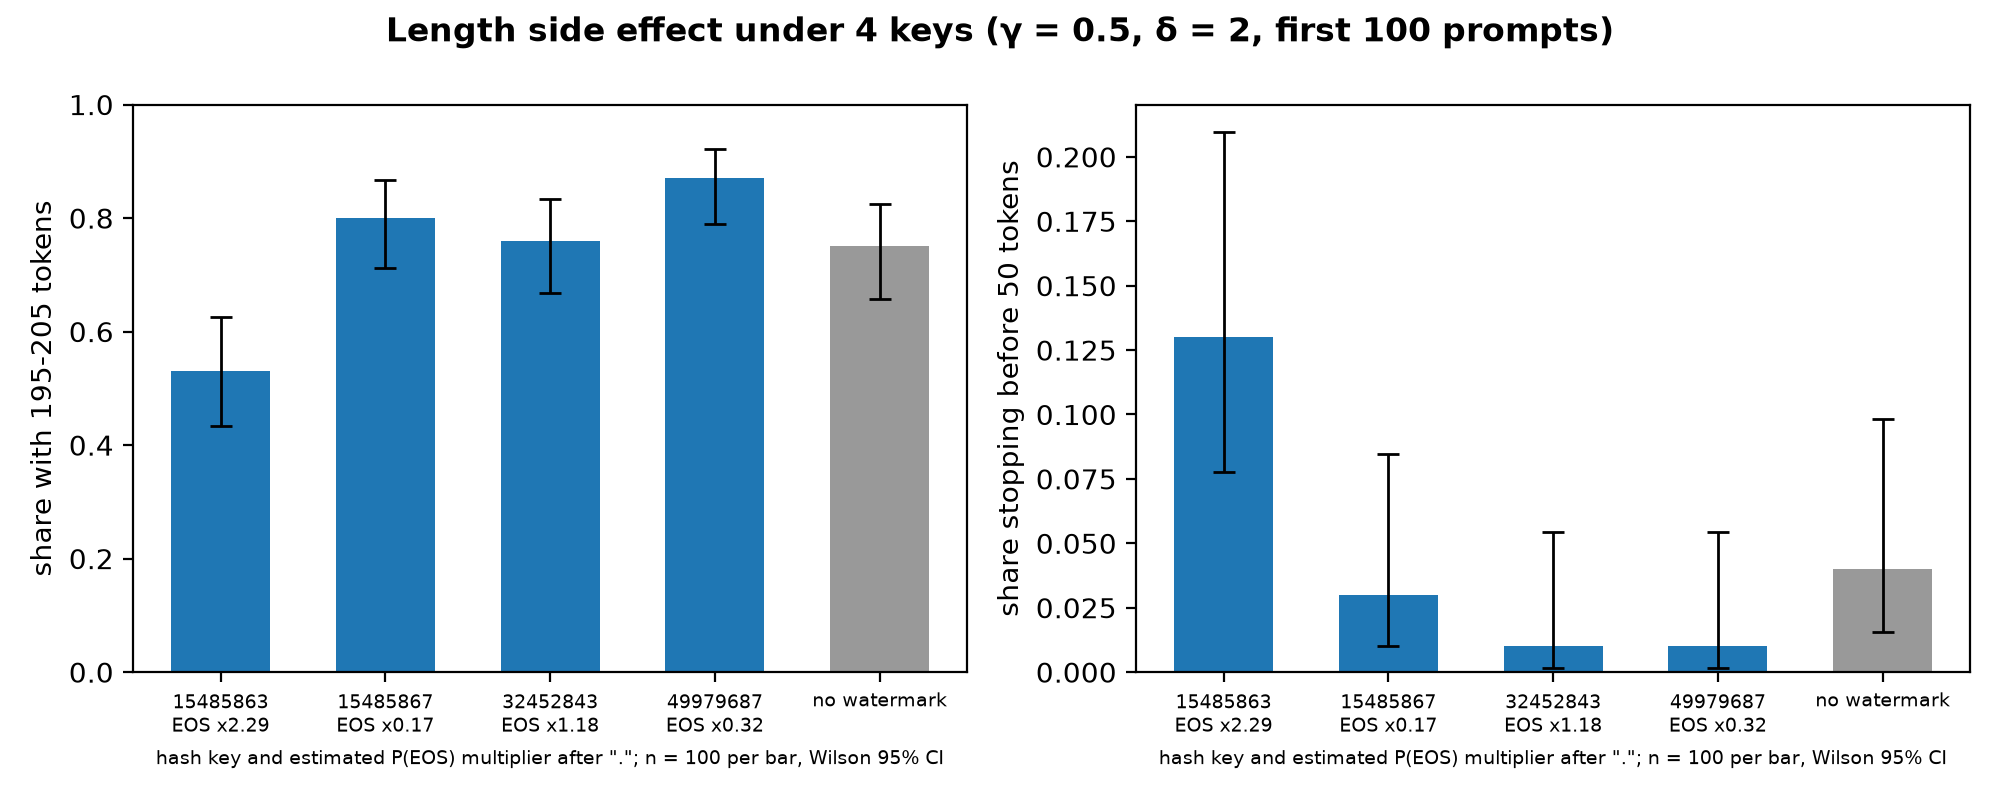

In [7]:
show("keys_eos.png")

---
##### Error rates and ROC
Table 8 and Fig. 4: negatives are the human baselines (primary) and δ = 0 generations.

In [8]:
paper8 = {("m-nom", 1, .5): (.767, .504), ("m-nom", 1, .25): (.729, .482), ("m-nom", 2, .5): (.984, .978),
          ("m-nom", 2, .25): (.994, .988), ("m-nom", 5, .5): (.996, .992), ("m-nom", 5, .25): (1., .998),
          ("8-beams", 1, .5): (.873, .812), ("8-beams", 1, .25): (.819, .770), ("8-beams", 2, .5): (.992, .984),
          ("8-beams", 2, .25): (.994, .990), ("8-beams", 5, .5): (1., 1.), ("8-beams", 5, .25): (1., 1.)}
paper4 = {("m-nom", .5, 10): (1., 11.6), ("m-nom", .25, 10): (1., 12.4), ("m-nom", .5, 5): (1., 9.1),
          ("m-nom", .25, 5): (1., 10.7), ("m-nom", .5, 2): (.998, 6.2), ("m-nom", .25, 2): (.998, 6.6),
          ("m-nom", .5, 1): (.985, 5.4), ("m-nom", .25, 1): (.989, 5.5), ("8-beams", .5, 10): (1., 1.2),
          ("8-beams", .25, 10): (1., 1.2), ("8-beams", .5, 5): (1., 1.2), ("8-beams", .25, 5): (1., 1.3),
          ("8-beams", .5, 2): (.999, 1.2), ("8-beams", .25, 2): (1., 1.3), ("8-beams", .5, 1): (.987, 1.2),
          ("8-beams", .25, 1): (.977, 1.2)}
count8 = {("m-nom", 1, .5): 506, ("m-nom", 1, .25): 506, ("m-nom", 2, .5): 507, ("m-nom", 2, .25): 505,
          ("m-nom", 5, .5): 504, ("m-nom", 5, .25): 503, ("8-beams", 1, .5): 495, ("8-beams", 1, .25): 496,
          ("8-beams", 2, .5): 496, ("8-beams", 2, .25): 496, ("8-beams", 5, .5): 496, ("8-beams", 5, .25): 496}


def verdict(ours_ci, p, n_paper):
    """'consistent' if the paper's point is inside our 95% CI, 'different' if the two Wilson CIs do not overlap,
    else 'borderline'."""
    pc = S.wilson(round(p * n_paper), n_paper)
    if ours_ci[0] - 1e-9 <= p <= ours_ci[1] + 1e-9:
        return "consistent"
    return "different" if (pc[1] < ours_ci[0] or pc[0] > ours_ci[1]) else "borderline"


tab, curves = [], {}
for samp, prefix in (("m-nom", "opt-news-m"), ("8-beams", "opt-news-beam8")):
    for d in (1, 2, 5):
        for g in (0.5, 0.25):
            cid = f"{prefix}-d{d}-g{g:g}"
            if not have(cid):
                continue
            rows = gen(cid)
            out, z = S.run_summary(rows, g, VO, hz[g])
            z_d0 = d0z[g]
            pz4, pz5 = paper8[(samp, d, g)]
            pa, pp = paper4[(samp, g, d)]
            tab.append(dict(sampling=samp, delta=d, gamma=g, count=out["count"], FPR_z4=out["FPR_z4"], TNR_z4=out["TNR_z4"],
                            TPR_z4=out["TPR_z4"], paper_TPR_z4=pz4, FNR_z4=out["FNR_z4"], FPR_z5=out["FPR_z5"],
                            TPR_z5=out["TPR_z5"], paper_TPR_z5=pz5, FPR_z4_delta0=float((z_d0 > 4).mean()),
                            AUC=out["AUC"], paper_AUC=pa, AUC_delta0=S.auc(z, z_d0), PPL_mean=out["PPL_mean"],
                            paper_PPL=pp, PPL_median=out["PPL_median"],
                            TPR_z4_lo=S.wilson_of(z > 4)[0], TPR_z4_hi=S.wilson_of(z > 4)[1],
                            TPR_z5_lo=S.wilson_of(z > 5)[0], TPR_z5_hi=S.wilson_of(z > 5)[1],
                            FPR_z4_hi=S.wilson_of(hz[g] > 4)[1],
                            paper_count=count8[(samp, d, g)],
                            vs_paper_z4=verdict(S.wilson_of(z > 4), pz4, count8[(samp, d, g)]),
                            vs_paper_z5=verdict(S.wilson_of(z > 5), pz5, count8[(samp, d, g)])))
            curves[f"{samp} δ={d} γ={g} (paper AUC {pa:.3f})"] = (*S.roc(z, hz[g]), out["AUC"])
tab8 = save("table8", pd.DataFrame(tab))
display(tab8)
if curves:
    PL.roc_curves(curves, "fig4_roc.png", f"Fig. 4: ROC, watermarked vs human baselines (counts in table8)")
base_ppl = pd.DataFrame([dict(text=name, n=len(p), PPL_mean=np.mean(p), PPL_median=np.median(p), paper_PPL=pp)
                         for name, p, pp in (("human baselines", [r["ppl"] for r in human if r["ppl"]], None),
                                             ("no watermark, multinomial", [r["ppl"] for r in d0 if r["ppl"]], 5.1),
                                             ("no watermark, 8 beams", [r["ppl"] for r in gen("opt-news-beam8-d0") if r["ppl"]]
                                              if have("opt-news-beam8-d0") else [], 1.2)) if len(p)])
save("ppl_baselines", base_ppl)
display(base_ppl)

,sampling,delta,gamma,count,FPR_z4,TNR_z4,TPR_z4,paper_TPR_z4,FNR_z4,FPR_z5,TPR_z5,paper_TPR_z5,FPR_z4_delta0,AUC,paper_AUC,AUC_delta0,PPL_mean,paper_PPL,PPL_median,TPR_z4_lo,TPR_z4_hi,TPR_z5_lo,TPR_z5_hi,FPR_z4_hi,paper_count,vs_paper_z4,vs_paper_z5
0,m-nom,1,0.50,300,0.0,1.0,0.700,0.767,0.300,0.0,0.367,0.504,0.002,0.997,0.985,0.995,5.716,5.4,5.660,0.646,0.749,0.314,0.423,0.004,506,borderline,different
1,m-nom,1,0.25,300,0.0,1.0,0.777,0.729,0.223,0.0,0.537,0.482,0.002,0.992,0.989,0.989,5.559,5.5,5.445,0.726,0.820,0.480,0.592,0.004,506,consistent,consistent
2,m-nom,2,0.50,497,0.0,1.0,0.986,0.984,0.014,0.0,0.980,0.978,0.002,0.999,0.998,0.999,6.533,6.2,6.430,0.971,0.993,0.963,0.989,0.004,507,consistent,consistent
3,m-nom,2,0.25,300,0.0,1.0,1.000,0.994,0.000,0.0,1.000,0.988,0.002,1.000,0.998,1.000,6.687,6.6,6.731,0.987,1.000,0.987,1.000,0.004,505,consistent,consistent
4,m-nom,5,0.50,300,0.0,1.0,1.000,0.996,0.000,0.0,1.000,0.992,0.002,1.000,1.000,1.000,9.233,9.1,9.328,0.987,1.000,0.987,1.000,0.004,504,consistent,consistent
5,m-nom,5,0.25,300,0.0,1.0,1.000,1.000,0.000,0.0,1.000,0.998,0.002,1.000,1.000,1.000,12.399,10.7,12.420,0.987,1.000,0.987,1.000,0.004,503,consistent,consistent
6,8-beams,1,0.50,100,0.0,1.0,0.850,0.873,0.150,0.0,0.750,0.812,0.002,0.991,0.987,0.990,1.574,1.2,1.447,0.767,0.907,0.657,0.825,0.004,495,consistent,consistent
7,8-beams,1,0.25,100,0.0,1.0,0.820,0.819,0.180,0.0,0.750,0.770,0.002,0.986,0.977,0.984,1.535,1.2,1.426,0.733,0.883,0.657,0.825,0.004,496,consistent,consistent
8,8-beams,2,0.50,150,0.0,1.0,0.993,0.992,0.007,0.0,0.987,0.984,0.002,1.000,0.999,1.000,1.629,1.2,1.563,0.963,0.999,0.953,0.996,0.004,496,consistent,consistent
9,8-beams,2,0.25,150,0.0,1.0,0.993,0.994,0.007,0.0,0.987,0.990,0.002,0.998,1.000,0.998,1.697,1.3,1.623,0.963,0.999,0.953,0.996,0.004,496,consistent,consistent


,text,n,PPL_mean,PPL_median,paper_PPL
0,human baselines,1000,11.061,9.927,NaN
1,"no watermark, multinomial",500,5.293,5.163,5.1
2,"no watermark, 8 beams",100,1.442,1.388,1.2


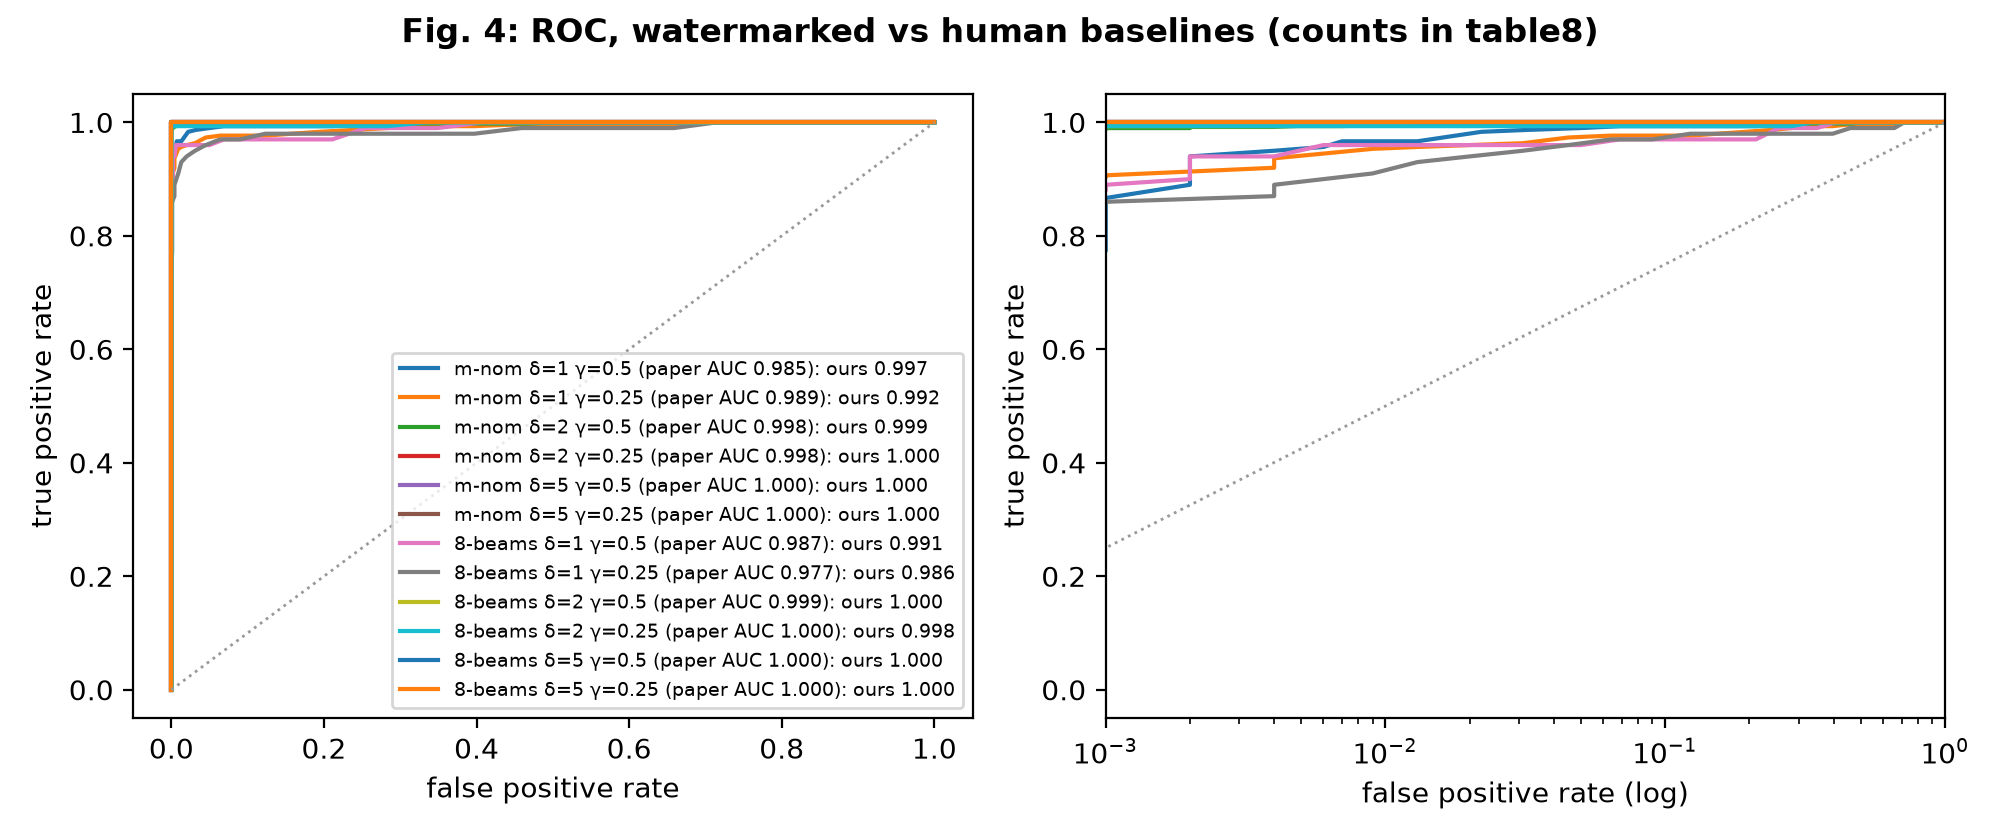

In [9]:
show("fig4_roc.png")

---
##### Strength vs quality
Fig. 2: mean z against oracle perplexity.

In [10]:
def zp(cid, g):
    rows = [r for r in gen(cid) if r["ppl"] is not None]
    return (np.mean([S.z_ranks(r["ranks"], g, VO) for r in rows]), np.mean([r["ppl"] for r in rows]), len(rows)) if rows else None

left, right, fig2 = [], [], []
for g in P.GAMMAS:
    for d in (0, 1, 2, 5, 10):
        cid = "opt-news-m-d0" if d == 0 else f"opt-news-m-d{d}-g{g:g}"
        if have(cid) and (v := zp(cid, g)):
            left.append((g, d, v[0], v[1]))
            fig2.append(dict(panel="multinomial", gamma=g, delta=d, z_mean=v[0], PPL_mean=v[1], n=v[2]))
for label, prefix in (("greedy", "opt-news-greedy"), ("4 beams", "opt-news-beam4"), ("8 beams", "opt-news-beam8")):
    for d in (0, 0.5, 1, 2, 5, 10):
        cid = f"{prefix}-d0" if d == 0 else f"{prefix}-d{d:g}-g0.5"
        if have(cid) and (v := zp(cid, 0.5)):
            right.append((label, d, v[0], v[1]))
            fig2.append(dict(panel=label, gamma=0.5, delta=d, z_mean=v[0], PPL_mean=v[1], n=v[2]))
fig2 = save("fig2_tradeoff", pd.DataFrame(fig2))
display(fig2)
if left:
    ns = fig2["n"]
    PL.tradeoff(left, right, "fig2_tradeoff.png", f"n = {ns.min()}-{ns.max()} per point")

,panel,gamma,delta,z_mean,PPL_mean,n
0,multinomial,0.10,0.0,-0.057,5.293,500
1,multinomial,0.10,1.0,4.045,5.388,100
2,multinomial,0.10,2.0,10.774,6.259,100
3,multinomial,0.10,5.0,32.625,13.672,100
4,multinomial,0.10,10.0,41.665,17.478,100
5,multinomial,0.25,0.0,-0.011,5.293,500
6,multinomial,0.25,1.0,5.167,5.559,300
7,multinomial,0.25,2.0,11.082,6.687,300
8,multinomial,0.25,5.0,21.275,12.399,300
9,multinomial,0.25,10.0,24.221,15.579,100


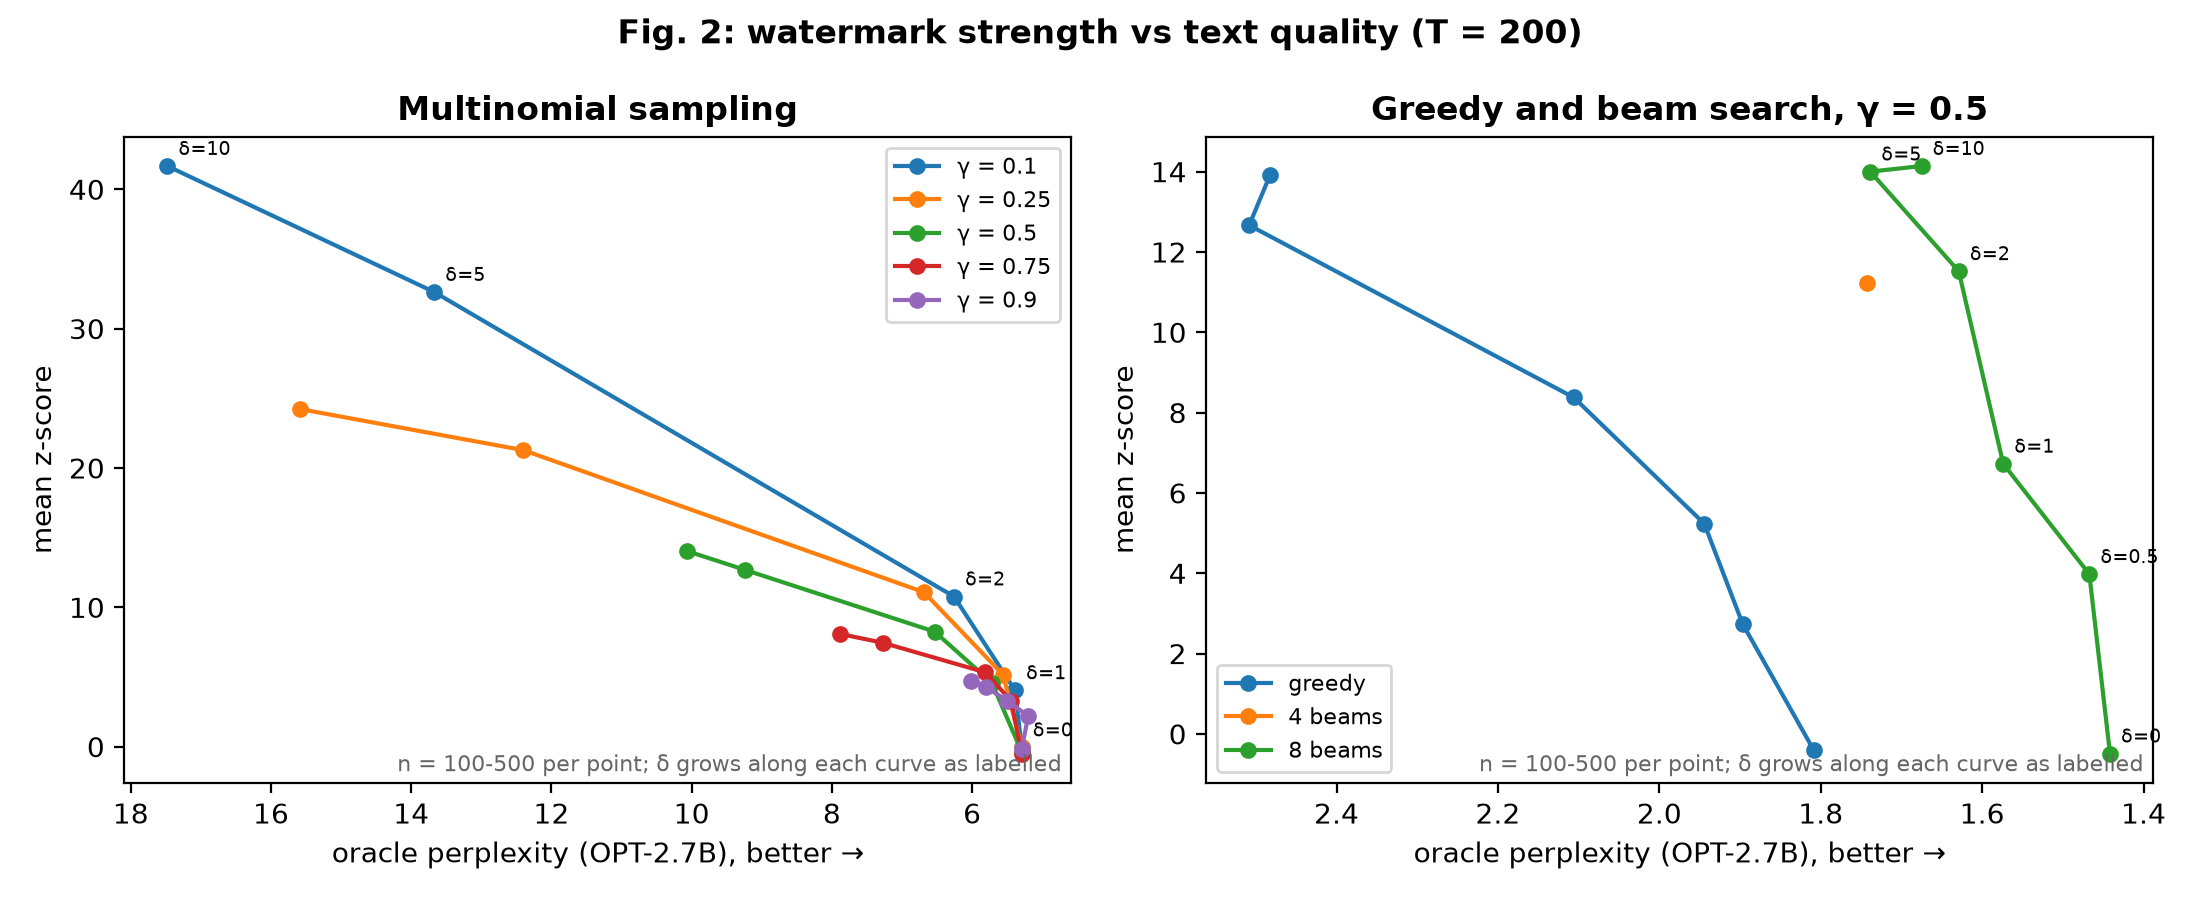

In [11]:
show("fig2_tradeoff.png")

---
##### Length
Fig. 3: mean z after the first T tokens, from the stored green flags.

In [12]:
Ts = list(range(2, 201, 2))
def series(prefix, g, deltas):
    out = {}
    for d in deltas:
        cid = f"{prefix}-d{d:g}-g{g:g}"
        if have(cid):
            rows = gen(cid)
            out[f"δ = {d:g}" if len(deltas) > 1 else f"γ = {g:g}"] = (Ts, S.mean_z_vs_T([S.green(r["ranks"], g, VO) for r in rows], g, Ts))
    return out
pa = {}
for g in P.GAMMAS:
    pa.update({f"γ = {g:g}": v for v in series("opt-news-m", g, [5]).values()})
panels = [("(a) multinomial, δ = 5", pa),
          ("(b) multinomial, γ = 0.25", series("opt-news-m", 0.25, [0.5, 1, 2, 5, 10])),
          ("(c) 8 beams, γ = 0.25", series("opt-news-beam8", 0.25, [0.5, 1, 2, 5, 10]))]
panels = [p for p in panels if p[1]]
fig3 = [dict(panel=t, series=k, T=T_, z_mean=z_) for t, s in panels for k, (a, b_) in s.items() for T_, z_ in zip(a, b_)]
fig3 = pd.DataFrame(fig3)
save("fig3_z_vs_T", fig3)
if panels:
    PL.z_vs_T(panels, "fig3_z_vs_T.png", "n per curve: see fig3 / table8")
    first5 = fig3[(fig3.z_mean > 5)].groupby(["panel", "series"]).T.min()
    display(first5.rename("first T with mean z > 5").to_frame())

first T with mean z > 5
panel                     series                           
(a) multinomial, δ = 5    γ = 0.1                         6
                          γ = 0.25                       12
                          γ = 0.5                        34
                          γ = 0.75                       94
(b) multinomial, γ = 0.25 δ = 1                         188
                          δ = 10                         10
                          δ = 2                          44
                          δ = 5                          12
(c) 8 beams, γ = 0.25     δ = 1                          88
                          δ = 10                         10
                          δ = 2                          24
                          δ = 5                          10

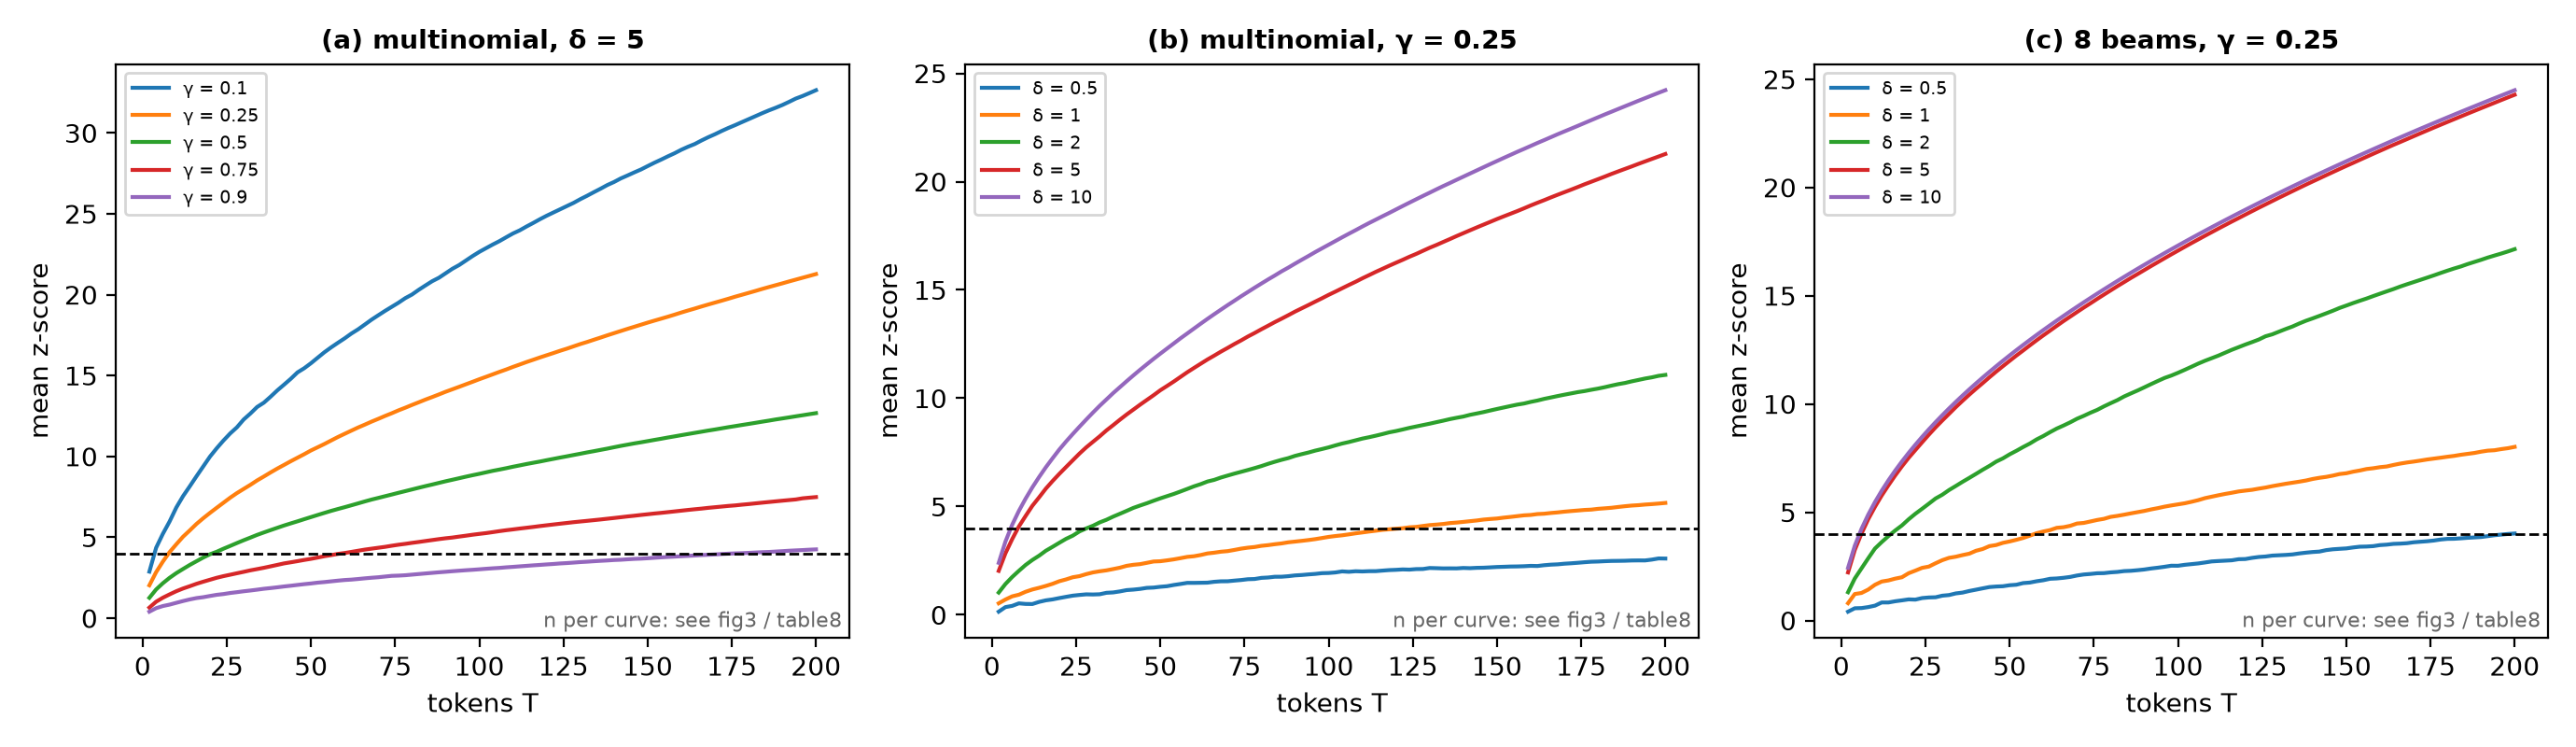

In [13]:
show("fig3_z_vs_T.png")

---
##### T5 attack
Table 9 and Fig. 5: γ = 0.5, δ = 2; attacked texts re-tokenized with OPT; AUC against unattacked human baselines.

In [14]:
paper9 = {"m-nom": [(0, .984, .977, .998, 6.3), (.1, .819, .577, .988, 13.1), (.3, .353, .127, .954, 21.2),
                    (.5, .094, .029, .838, 28.4), (.7, .039, .012, .696, 33.9)],
          "beams": [(0, .998, .998, None, None), (.1, .834, .751, None, None), (.3, .652, .521, None, None),
                    (.5, .464, .299, None, None), (.7, .299, .155, None, None)]}
sc_path = C.raw_path("attacks", "scored")
scored = pd.DataFrame(C.load_rows(sc_path)) if os.path.exists(sc_path) else pd.DataFrame()
if len(scored):
    scored["z"] = scored["z"].fillna(0.0)    # an empty attacked text carries no evidence: z = 0
t9, ours5 = [], {}
if len(scored):
    for samp, src, att in (("m-nom, multi-word T5", "wm", "t5"), ("m-nom, single-word T5", "wm", "t5w"), ("beams", "beam", "t5")):
        sub = scored[(scored.src == src) & (scored.attack.isin(["none", att]))]
        if att == "t5w":
            ids_w = set(scored[(scored.attack == "t5w") & (scored.src == "wm")].idx)
            sub = sub[sub.idx.isin(ids_w)]
        if not len(sub[sub.attack == att]) and att == "t5" and src == "beam":
            pass
        for eps, grp in sub.groupby("level"):
            z = grp.z.values
            p = {e: v for e, *v in paper9["beams" if src == "beam" else "m-nom"]}[float(eps)]
            t9.append(dict(sampling=samp, eps=float(eps), count=len(grp), TPR_z4=(z > 4).mean(), paper_TPR_z4=p[0],
                           TPR_z5=(z > 5).mean(), paper_TPR_z5=p[1], AUC=S.auc(z, hz[0.5]), paper_AUC=p[2],
                           PPL_mean=grp.ppl.mean(), paper_PPL=p[3], tokens_after=grp["T"].mean(),
                           words_replaced=grp.succ.mean() if "succ" in grp and float(eps) > 0 else 0.0,
                           TPR_z4_lo=S.wilson_of(z > 4)[0], TPR_z4_hi=S.wilson_of(z > 4)[1],
                           TPR_z5_lo=S.wilson_of(z > 5)[0], TPR_z5_hi=S.wilson_of(z > 5)[1],
                           vs_paper_z4=verdict(S.wilson_of(z > 4), p[0], 489 if src == "beam" else (507 if float(eps) == 0 else 487)),
                           vs_paper_z5=verdict(S.wilson_of(z > 5), p[1], 489 if src == "beam" else (507 if float(eps) == 0 else 487))))
            ours5.setdefault(samp, []).append((float(eps), (z > 4).mean(), (z > 5).mean()))
t9 = save("table9_t5", pd.DataFrame(t9)) if t9 else pd.DataFrame()
display(t9)
if ours5:
    PL.t5_attack({k: v for k, v in ours5.items() if k != "beams"}, {"m-nom (paper)": [(e, a, b_) for e, a, b_, *_ in paper9["m-nom"]]},
                 "fig5_t5_attack.png", "Fig. 5 / Tab. 9: T5 span attack, γ = 0.5, δ = 2")

,sampling,eps,count,TPR_z4,paper_TPR_z4,TPR_z5,paper_TPR_z5,AUC,paper_AUC,PPL_mean,paper_PPL,tokens_after,words_replaced,TPR_z4_lo,TPR_z4_hi,TPR_z5_lo,TPR_z5_hi,vs_paper_z4,vs_paper_z5
0,"m-nom, multi-word T5",0.0,200,1.000,0.984,0.985,0.977,1.000,0.998,6.553,6.3,199.945,0.00,0.981,1.000,0.957,0.995,consistent,consistent
1,"m-nom, multi-word T5",0.1,200,0.955,0.819,0.890,0.577,1.000,0.988,8.053,13.1,231.595,20.00,0.917,0.976,0.839,0.926,different,different
2,"m-nom, multi-word T5",0.3,200,0.495,0.353,0.295,0.127,0.992,0.954,9.918,21.2,294.690,60.00,0.426,0.564,0.236,0.362,different,different
3,"m-nom, single-word T5",0.0,100,1.000,0.984,0.980,0.977,1.000,0.998,6.714,6.3,199.950,0.00,0.963,1.000,0.930,0.994,consistent,consistent
4,"m-nom, single-word T5",0.1,100,0.990,0.819,0.870,0.577,1.000,0.988,9.243,13.1,200.770,20.00,0.946,0.998,0.790,0.922,different,different
5,"m-nom, single-word T5",0.3,100,0.240,0.353,0.090,0.127,0.996,0.954,16.040,21.2,202.280,59.97,0.167,0.332,0.048,0.162,borderline,consistent
6,"m-nom, single-word T5",0.5,100,0.020,0.094,0.000,0.029,0.868,0.838,24.792,28.4,205.510,99.87,0.006,0.070,0.000,0.037,different,consistent
7,"m-nom, single-word T5",0.7,100,0.010,0.039,0.000,0.012,0.652,0.696,33.473,33.9,209.870,130.41,0.002,0.054,0.000,0.037,consistent,consistent
8,beams,0.0,150,0.993,0.998,0.987,0.998,1.000,NaN,1.632,NaN,199.793,0.00,0.963,0.999,0.953,0.996,consistent,borderline


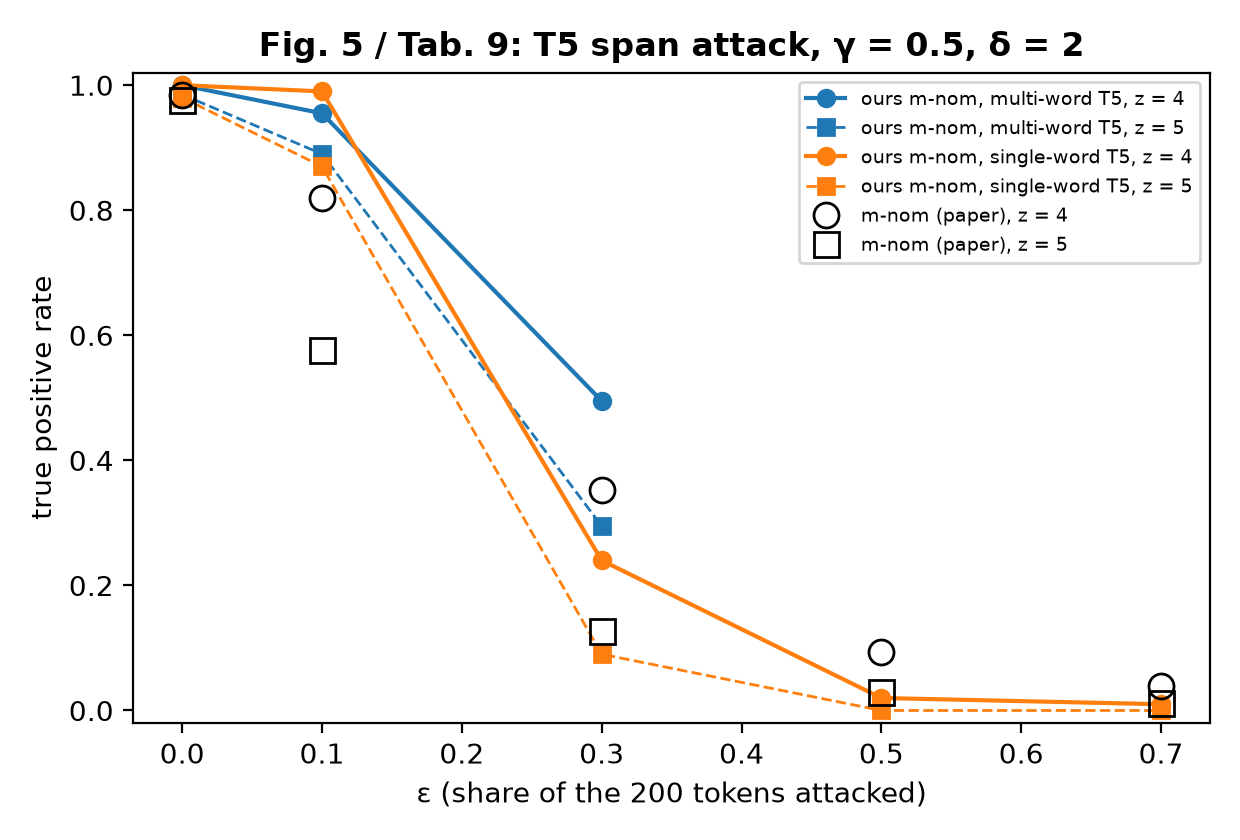

In [15]:
show("fig5_t5_attack.png")

---
##### Theory vs data
Fig. 7 and Extension 1a: observed green fraction against Theorem 4.2, with S from the raw distribution (paper) and from the distribution actually sampled (τ = 0.7).

In [16]:
g = 0.5
fig7 = []
for d in (0, 0.5, 1, 2, 5, 10):
    cid = "opt-news-m-d0" if d == 0 else f"opt-news-m-d{d:g}-g0.5"
    if not have(cid):
        continue
    rows = gen(cid)
    gf = np.array([S.green(r["ranks"], g, VO).mean() for r in rows])
    sp = np.mean([np.mean(r["S_paper"]) for r in rows]) if d else 1.0
    ss = np.mean([np.mean(r["S_sampled"]) for r in rows]) if d else 1.0
    fig7.append(dict(delta=d, n=len(rows), obs_mean=gf.mean(), obs_q25=np.percentile(gf, 25), obs_q75=np.percentile(gf, 75),
                     S_paper=sp, S_sampled=ss, bound_paper=S.thm42(sp, g, d, 1)["frac"],
                     bound_corrected=S.thm42(ss, g, d / P.TEMP, 1)["frac"]))
fig7 = save("fig7_theory", pd.DataFrame(fig7))
display(fig7)
paper7 = {"paper observed (read off Fig. 7)": ([0, .5, 1, 2, 5, 10], [.53, .60, .68, .80, .94, .99]),
          "paper bound (read off Fig. 7)": ([0, .5, 1, 2, 5, 10], [.50, .59, .63, .71, .76, .76])}
if len(fig7):
    nn = f"n = {fig7.n.min()}-{fig7.n.max()} per δ"
    PL.bound_vs_observed(fig7.delta, fig7.obs_mean, fig7.obs_q25, fig7.obs_q75, {"Thm 4.2 bound (paper: S on softmax(l), α = e^δ)": fig7.bound_paper},
                         "fig7_theory.png", "Fig. 7: green fraction vs δ (γ = 0.5)", paper7, nn)
    PL.bound_vs_observed(fig7.delta, fig7.obs_mean, fig7.obs_q25, fig7.obs_q75,
                         {"paper bound: softmax(l), α = e^δ": fig7.bound_paper,
                          "corrected bound: softmax(l/τ), α = e^(δ/τ)": fig7.bound_corrected},
                         "ext1a_bound_vs_observed.png", "Ext. 1a: Theorem 4.2 on the sampled distribution (γ = 0.5)", None, nn)

,delta,n,obs_mean,obs_q25,obs_q75,S_paper,S_sampled,bound_paper,bound_corrected
0,0.0,500,0.487,0.455,0.515,1.000,1.000,0.500,0.500
1,0.5,100,0.586,0.560,0.611,0.925,0.858,0.575,0.576
2,1.0,300,0.661,0.635,0.690,0.871,0.778,0.637,0.628
3,2.0,497,0.792,0.765,0.825,0.813,0.714,0.716,0.675
4,5.0,300,0.948,0.930,0.970,0.768,0.684,0.762,0.683
5,10.0,100,0.997,0.995,1.000,0.742,0.665,0.742,0.665


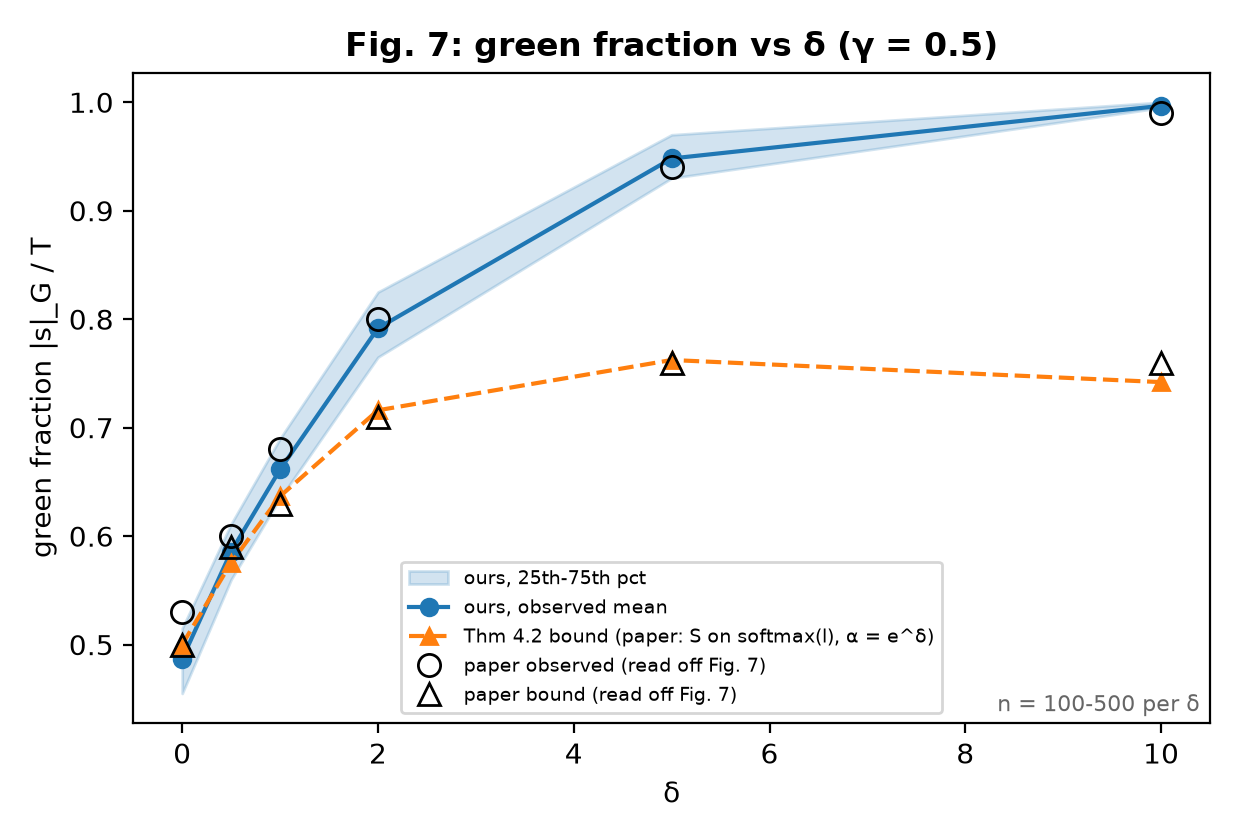

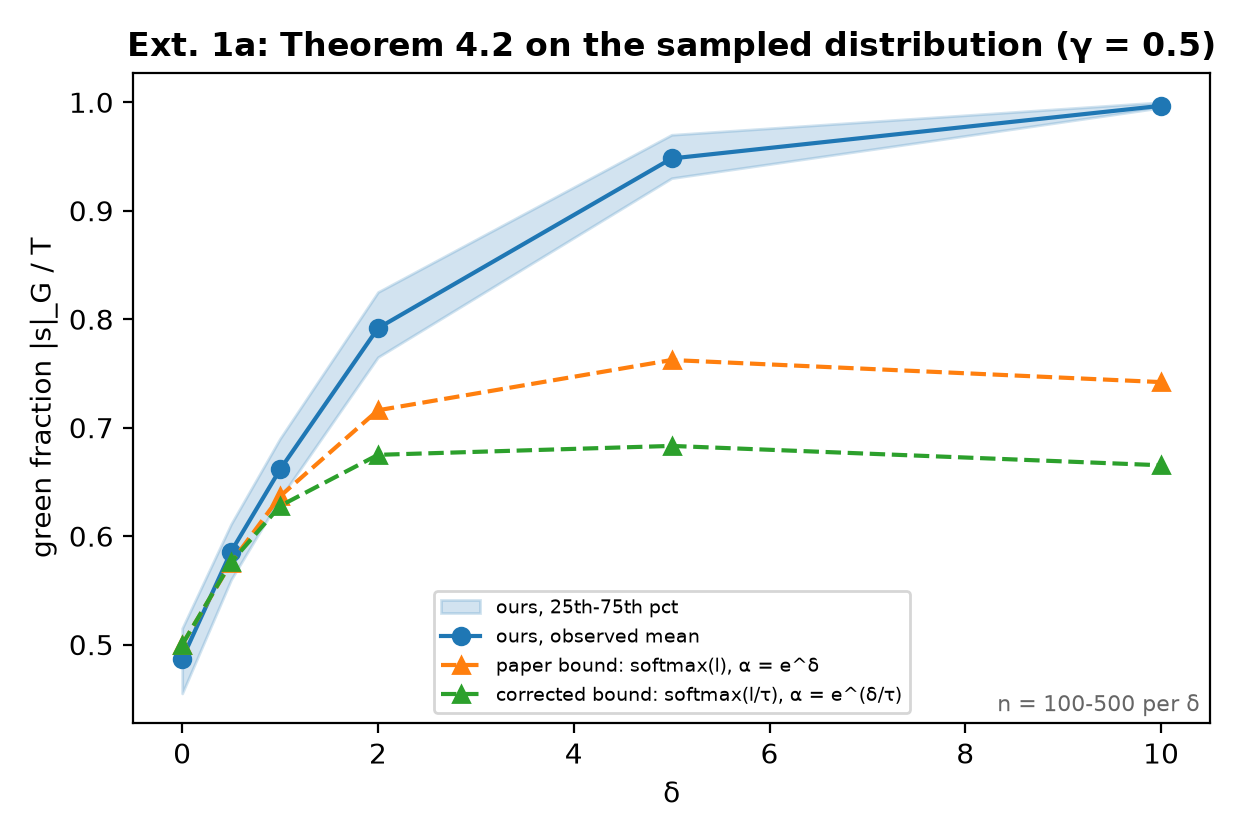

In [17]:
show("fig7_theory.png", "ext1a_bound_vs_observed.png")

In [18]:
# Ext 1a on every multinomial run: is each bound a valid lower bound, per run and per sequence?
e1a = []
for cid, c in sorted(CFG.items()):
    if not (cid.startswith("opt-news-m-") and c["delta"] > 0 and have(cid)):
        continue
    rows = gen(cid)
    g, d = c["gamma"], c["delta"]
    gf = np.array([S.green(r["ranks"], g, VO).mean() for r in rows])
    bp = np.array([S.thm42(np.mean(r["S_paper"]), g, d, 1)["frac"] for r in rows])
    bc = np.array([S.thm42(np.mean(r["S_sampled"]), g, d / P.TEMP, 1)["frac"] for r in rows])
    e1a.append(dict(gamma=g, delta=d, n=len(rows), observed=gf.mean(), bound_paper=bp.mean(), bound_corrected=bc.mean(),
                    paper_valid=gf.mean() >= bp.mean(), corrected_valid=gf.mean() >= bc.mean(),
                    gap_paper=gf.mean() - bp.mean(), gap_corrected=gf.mean() - bc.mean(),
                    seq_below_paper=(gf < bp).mean(), seq_below_corrected=(gf < bc).mean()))
e1a = save("ext1a_bounds", pd.DataFrame(e1a).sort_values(["gamma", "delta"]) if e1a else pd.DataFrame())
display(e1a)

,gamma,delta,n,observed,bound_paper,bound_corrected,paper_valid,corrected_valid,gap_paper,gap_corrected,seq_below_paper,seq_below_corrected
2,0.10,1.0,100,0.186,0.172,0.175,True,True,0.014,0.011,0.370,0.430
12,0.10,2.0,100,0.329,0.264,0.247,True,True,0.065,0.081,0.090,0.040
17,0.10,5.0,100,0.792,0.356,0.253,True,True,0.436,0.539,0.000,0.000
7,0.10,10.0,100,0.984,0.314,0.218,True,True,0.670,0.766,0.000,0.000
0,0.25,0.5,100,0.329,0.312,0.314,True,True,0.017,0.015,0.380,0.400
3,0.25,1.0,300,0.408,0.377,0.375,True,True,0.031,0.034,0.270,0.257
13,0.25,2.0,300,0.589,0.488,0.448,True,True,0.101,0.141,0.017,0.003
18,0.25,5.0,300,0.901,0.559,0.451,True,True,0.343,0.450,0.000,0.000
8,0.25,10.0,100,0.992,0.531,0.426,True,True,0.461,0.565,0.000,0.000
1,0.50,0.5,100,0.586,0.575,0.576,True,True,0.010,0.010,0.400,0.400


---
##### Extension 1
Entropy decides: news vs code vs short factual answers, base vs instruction-tuned model.

In [19]:
CELLS = [("news", "opt", "opt-news-m-d2-g0.25", "opt-news-m-d0"), ("code", "opt", "opt-code-m-d2-g0.25", "opt-code-m-d0"),
         ("qa", "opt", "opt-qa-greedy-d2-g0.5", "opt-qa-greedy-d0"),
         ("news", "qwen", "qwen-news-m-d2-g0.25", "qwen-news-m-d0"), ("code", "qwen", "qwen-code-m-d2-g0.25", "qwen-code-m-d0"),
         ("qa", "qwen", "qwen-qa-greedy-d2-g0.5", "qwen-qa-greedy-d0"),
         ("news", "qwen-it", "qwen-it-news-m-d2-g0.25", "qwen-it-news-m-d0"),
         ("code", "qwen-it", "qwen-it-code-m-d2-g0.25", "qwen-it-code-m-d0"),
         ("qa", "qwen-it", "qwen-it-qa-greedy-d2-g0.5", "qwen-it-qa-greedy-d0"),
         ("news δ=4", "qwen-it", "qwen-it-news-m-d4-g0.25", "qwen-it-news-m-d0")]


def cell_rows(cid, n):
    return [r for r in C.load_gen(cid) if r["T"] > 0][:n]


def ttz_norep(r, g, v):
    """Tokens (original positions) until z ignoring repeated pairs reaches 4."""
    keep = S.first_occurrence(r["ids"])
    t = S.tokens_to_z(S.green(r["ranks"], g, v)[keep], g)
    return np.flatnonzero(keep)[t - 1] + 1 if t else np.inf


e1, cells, tt = [], {}, []
for dom, m, cid, nid in CELLS:
    if not (have(cid) and have(nid)):
        continue
    c = CFG[cid]
    n = P.N_EXT if dom.startswith("news") else c["n"]
    pos, neg = cell_rows(cid, n), cell_rows(nid, n)
    g, d, tau = c["gamma"], c["delta"], (P.TEMP if c["decode"] == "sample" else 1.0)
    zp_ = np.array([S.z_ranks(r["ranks"], g, V[m]) for r in pos])
    zn_ = np.array([S.z_ranks(r["ranks"], g, V[m]) for r in neg])
    zpr = np.array([S.z_norep(r["ranks"], r["ids"], g, V[m]) for r in pos])
    znr = np.array([S.z_norep(r["ranks"], r["ids"], g, V[m]) for r in neg])
    ttr = np.array([ttz_norep(r, g, V[m]) for r in pos])
    gl = [S.green(r["ranks"], g, V[m]) for r in pos]
    ttz = np.array([S.tokens_to_z(x, g) or np.inf for x in gl])
    ttn = np.array([S.tokens_to_z(S.green(r["ranks"], g, V[m]), g) or np.inf for r in neg])
    for r, x in zip(pos, gl):
        r.update(gf=x.mean(), S_seq=np.mean(r["S_paper"]), Ss_seq=np.mean(r["S_sampled"]), H_seq=np.mean(r["H"]),
                 pred_paper=S.thm42(np.mean(r["S_paper"]), g, d, 1)["frac"],
                 pred_corr=S.thm42(np.mean(r["S_sampled"]), g, d / tau, 1)["frac"], zz=S.z_of(x, g),
                 zr=S.z_norep(r["ranks"], r["ids"], g, V[m]))
    tpr1, thr = S.tpr_at_fpr(zp_, zn_, 0.01)
    tpr1r, thrr = S.tpr_at_fpr(zpr, znr, 0.01)
    row = dict(domain=dom, model=m, gamma=g, delta=d, n=len(pos), n_neg=len(neg), T_mean=np.mean([r["T"] for r in pos]),
               S_paper=np.mean(np.concatenate([r["S_paper"] for r in pos])),
               S_sampled=np.mean(np.concatenate([r["S_sampled"] for r in pos])),
               H=np.mean(np.concatenate([r["H"] for r in pos])), H_nowm=np.mean(np.concatenate([r["H"] for r in neg])),
               z_mean=zp_.mean(), z_mean_nowm=zn_.mean(), TPR_z4=(zp_ > 4).mean(), FPR_z4=(zn_ > 4).mean(),
               TPR_1pctFPR=tpr1, thr_1pctFPR=thr, green_frac=np.mean([r["gf"] for r in pos]),
               pred_paper=np.mean([r["pred_paper"] for r in pos]), pred_corrected=np.mean([r["pred_corr"] for r in pos]),
               seq_below_paper=np.mean([r["gf"] < r["pred_paper"] for r in pos]),
               seq_below_corrected=np.mean([r["gf"] < r["pred_corr"] for r in pos]),
               tokens_to_z4_median=float(np.median(ttz)), never_z4=np.mean(np.isinf(ttz)),
               neg_ever_z4=np.mean(~np.isinf(ttn)),
               z_norep_mean=zpr.mean(), z_norep_mean_nowm=znr.mean(), TPR_z4_norep=(zpr > 4).mean(),
               FPR_z4_norep=(znr > 4).mean(), TPR_1pctFPR_norep=tpr1r, thr_1pctFPR_norep=thrr,
               tokens_to_z4_norep_median=float(np.median(ttr)), never_z4_norep=np.mean(np.isinf(ttr)),
               TPR_z4_lo=S.wilson_of(zp_ > 4)[0], TPR_z4_hi=S.wilson_of(zp_ > 4)[1],
               TPR_1pct_lo=S.wilson_of(zp_ > thr)[0], TPR_1pct_hi=S.wilson_of(zp_ > thr)[1],
               TPR_1pct_norep_lo=S.wilson_of(zpr > thrr)[0], TPR_1pct_norep_hi=S.wilson_of(zpr > thrr)[1],
               never_lo=S.wilson_of(np.isinf(ttz))[0], never_hi=S.wilson_of(np.isinf(ttz))[1],
               tokens_med_lo=S.boot_median(ttz)[0], tokens_med_hi=S.boot_median(ttz)[1],
               tokens_med_norep_lo=S.boot_median(ttr)[0], tokens_med_norep_hi=S.boot_median(ttr)[1])
    if "ppl" in pos[0] and pos[0]["ppl"] is not None:
        row["PPL_mean"] = np.mean([r["ppl"] for r in pos if r["ppl"]])
        row["PPL_mean_nowm"] = np.mean([r["ppl"] for r in neg if r["ppl"]]) if neg[0]["ppl"] is not None else np.nan
    if dom == "qa":
        em_w = np.array([C.qa_scores(r["text"], r["aliases"]) for r in pos])
        em_n = np.array([C.qa_scores(r["text"], r["aliases"]) for r in neg])
        row.update(EM_nowm=em_n[:, 0].mean(), EM_wm=em_w[:, 0].mean(), F1_nowm=em_n[:, 1].mean(), F1_wm=em_w[:, 1].mean(),
                   EM_nowm_lo=S.wilson_of(em_n[:, 0] > 0)[0], EM_nowm_hi=S.wilson_of(em_n[:, 0] > 0)[1],
                   EM_wm_lo=S.wilson_of(em_w[:, 0] > 0)[0], EM_wm_hi=S.wilson_of(em_w[:, 0] > 0)[1])
    e1.append(row)
    if not dom.startswith("news δ"):
        cells[(dom, m)] = pos
e1 = save("ext1b_cells", pd.DataFrame(e1))
display(e1)

,domain,model,gamma,delta,n,n_neg,T_mean,S_paper,S_sampled,H,H_nowm,z_mean,z_mean_nowm,TPR_z4,FPR_z4,TPR_1pctFPR,thr_1pctFPR,green_frac,pred_paper,pred_corrected,...,TPR_1pct_lo,TPR_1pct_hi,TPR_1pct_norep_lo,TPR_1pct_norep_hi,never_lo,never_hi,tokens_med_lo,tokens_med_hi,tokens_med_norep_lo,tokens_med_norep_hi,PPL_mean,PPL_mean_nowm,EM_nowm,EM_wm,F1_nowm,F1_wm,EM_nowm_lo,EM_nowm_hi,EM_wm_lo,EM_wm_hi
0,news,opt,0.25,2.0,200,200,180.060,0.695,0.532,2.398,2.412,10.306,0.031,0.975,0.000,0.990,3.266,0.584,0.494,0.453,...,0.964,0.997,0.964,0.997,0.003,0.036,20.0,27.0,21.0,30.0,6.888,5.204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,code,opt,0.25,2.0,164,164,191.793,0.453,0.349,0.738,0.663,3.762,-2.881,0.463,0.006,0.524,2.613,0.372,0.326,0.300,...,0.448,0.599,0.540,0.687,0.418,0.570,135.0,inf,inf,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,qa,opt,0.50,2.0,500,500,16.000,0.771,0.771,2.142,2.059,1.432,-0.414,0.000,0.000,0.518,1.000,0.679,0.679,0.679,...,0.474,0.561,0.656,0.737,0.977,0.996,inf,inf,inf,inf,NaN,NaN,0.000,0.004,0.002,0.028,0.000,0.008,0.001,0.014
3,news,qwen,0.25,2.0,198,198,175.520,0.709,0.545,2.480,2.519,10.491,0.056,0.975,0.000,0.995,3.079,0.597,0.506,0.466,...,0.972,0.999,0.972,0.999,0.005,0.044,24.0,27.0,24.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,code,qwen,0.25,2.0,164,164,131.866,0.462,0.362,0.683,0.585,3.353,0.016,0.329,0.018,0.244,4.736,0.382,0.342,0.320,...,0.185,0.315,0.436,0.588,0.521,0.670,inf,inf,inf,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,qa,qwen,0.50,2.0,500,500,5.490,0.771,0.771,1.765,1.741,1.183,-0.236,0.000,0.000,0.142,1.897,0.787,0.701,0.701,...,0.114,0.175,0.127,0.190,0.989,1.000,inf,inf,inf,inf,NaN,NaN,0.072,0.070,0.111,0.108,0.052,0.098,0.051,0.096
6,news,qwen-it,0.25,2.0,200,200,183.780,0.699,0.541,2.305,1.963,10.117,0.117,0.950,0.000,0.990,2.613,0.572,0.493,0.458,...,0.964,0.997,0.964,0.997,0.020,0.077,24.0,29.0,24.0,29.0,9.548,5.673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,code,qwen-it,0.25,2.0,164,164,144.768,0.446,0.354,0.523,0.430,2.574,-0.115,0.220,0.000,0.457,2.548,0.341,0.313,0.299,...,0.383,0.534,0.412,0.564,0.659,0.794,inf,inf,inf,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,qa,qwen-it,0.50,2.0,500,500,5.770,0.718,0.718,1.285,1.184,0.803,-0.053,0.000,0.000,0.054,2.000,0.693,0.648,0.648,...,0.037,0.077,0.036,0.075,0.989,1.000,inf,inf,inf,inf,NaN,NaN,0.202,0.212,0.279,0.269,0.169,0.239,0.178,0.250
9,news δ=4,qwen-it,0.25,4.0,200,200,183.850,0.704,0.554,2.990,1.963,18.687,0.117,0.990,0.000,0.990,2.613,0.847,0.658,0.542,...,0.964,0.997,0.964,0.997,0.003,0.036,8.0,8.0,8.0,8.0,25.556,5.673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
if cells:
    PL.scatter_cells(cells, "H_seq", "zr", "ext1b_z_vs_entropy.png", "Ext. 1b: z (repeated pairs ignored) vs entropy",
                     "mean Shannon entropy of the model's next-token distribution (nats)", "z-score, repeated (context, token) pairs ignored", hline=4)
    PL.scatter_cells(cells, "H_seq", "zz", "ext1b_z_vs_entropy_repeats.png", "Ext. 1b: z (repeats counted, paper) vs entropy",
                     "mean Shannon entropy of the model's next-token distribution (nats)", "z-score (repeats counted)", hline=4)
    PL.scatter_cells(cells, "pred_corr", "gf", "ext1b_theory_vs_observed.png",
                     "Ext. 1b: Thm 4.2 prediction (sampled distribution) vs observed",
                     "predicted green fraction (lower bound, own S_sampled)", "observed green fraction", diag=True)
    PL.scatter_cells(cells, "pred_paper", "gf", "ext1b_theory_vs_observed_paper.png",
                     "Ext. 1b: Thm 4.2 prediction (paper's S) vs observed",
                     "predicted green fraction (lower bound, own S_paper)", "observed green fraction", diag=True)
    sel = e1[~e1.domain.str.startswith("news δ")]
    PL.tokens_to_detect([f"{a}, {b}" for a, b in zip(sel.domain, sel.model)],
                        [None if np.isinf(v) else v for v in sel.tokens_to_z4_median], list(sel.never_z4),
                        "ext1b_tokens_to_detect.png", "Ext. 1b: tokens needed to reach z = 4",
                        list(sel.tokens_med_lo), list(sel.tokens_med_hi))
    PL.tokens_to_detect([f"{a}, {b}" for a, b in zip(sel.domain, sel.model)],
                        [None if np.isinf(v) else v for v in sel.tokens_to_z4_norep_median], list(sel.never_z4_norep),
                        "ext1b_tokens_to_detect_norep.png", "Ext. 1b: tokens to reach z = 4, repeated pairs ignored",
                        list(sel.tokens_med_norep_lo), list(sel.tokens_med_norep_hi))
qa = e1[e1.domain == "qa"] if len(e1) else e1
if len(qa):
    t10 = pd.DataFrame([dict(model="FLAN-UL2 (paper)", EM_nowm=.374, EM_wm=.336, F1_nowm=.415, F1_wm=.378, z_nowm=-.007, z_wm=.402),
                        dict(model="BLOOMZ (paper)", EM_nowm=.296, EM_wm=.259, F1_nowm=.343, F1_wm=.312, z_nowm=.008, z_wm=.255)]
                       + [dict(model=r.model, EM_nowm=r.EM_nowm, EM_wm=r.EM_wm, F1_nowm=r.F1_nowm, F1_wm=r.F1_wm,
                               z_nowm=r.z_mean_nowm, z_wm=r.z_mean) for r in qa.itertuples()])
    with open(os.path.join("figures", "ext1b_triviaqa.md"), "w") as f:
        f.write("TriviaQA validation (first 500), greedy, up to 16 new tokens, γ = 0.5, δ = 2. Exact match against "
                "normalized aliases (first line of the answer).\n\n" + t10.to_markdown(index=False, floatfmt=".3f") + "\n")
    display(t10)

,model,EM_nowm,EM_wm,F1_nowm,F1_wm,z_nowm,z_wm
0,FLAN-UL2 (paper),0.374,0.336,0.415,0.378,-0.007,0.402
1,BLOOMZ (paper),0.296,0.259,0.343,0.312,0.008,0.255
2,opt,0.000,0.004,0.002,0.028,-0.414,1.432
3,qwen,0.072,0.070,0.111,0.108,-0.236,1.183
4,qwen-it,0.202,0.212,0.279,0.269,-0.053,0.803


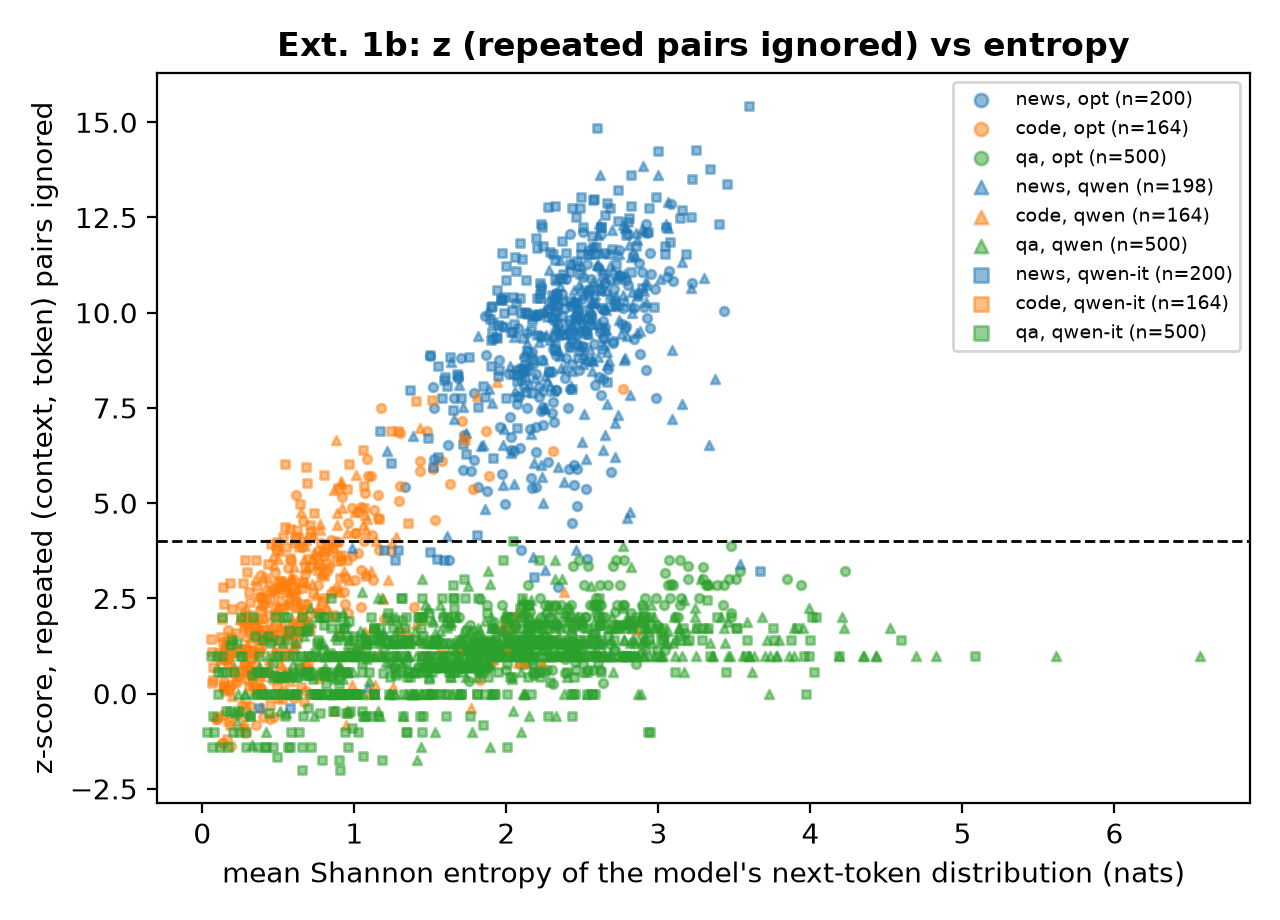

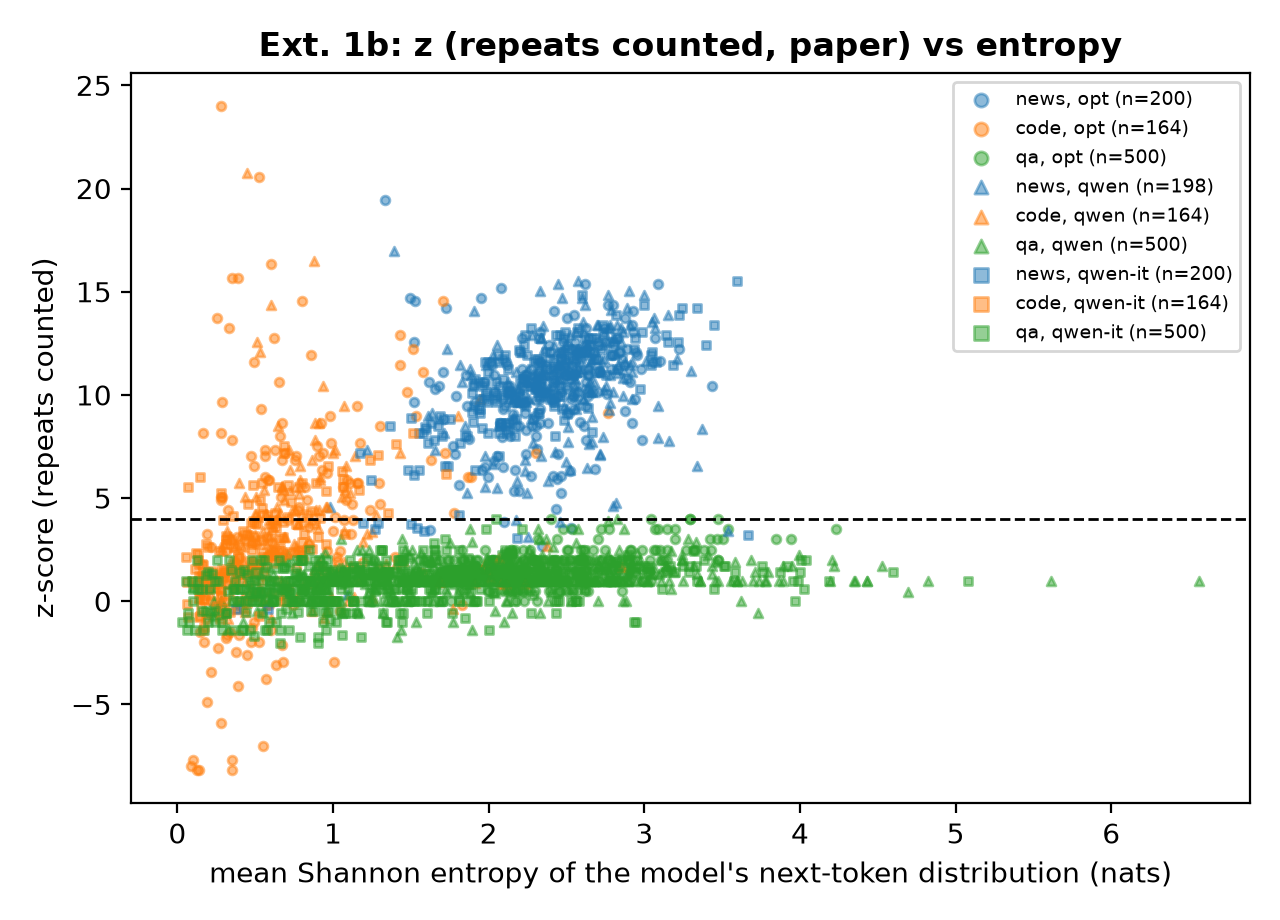

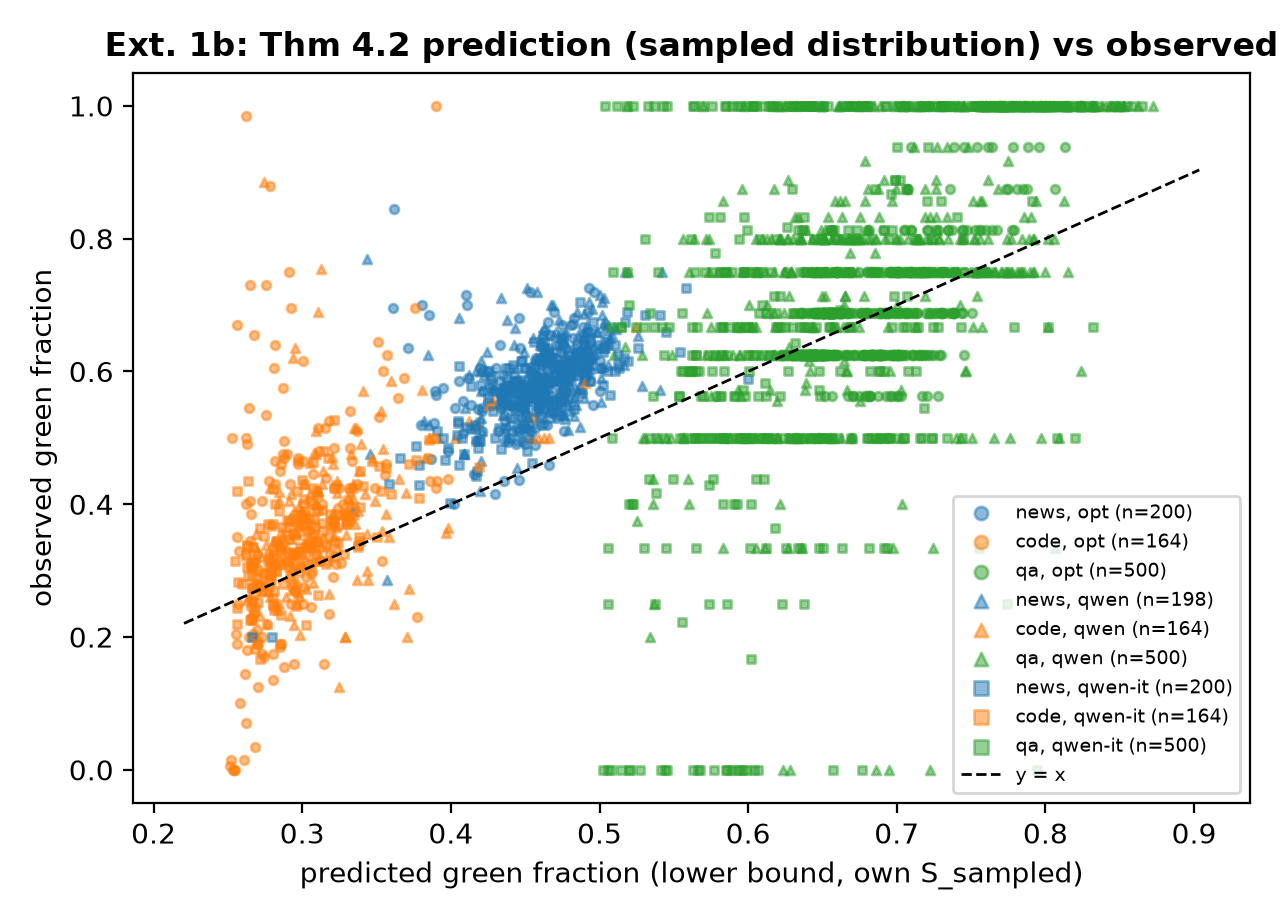

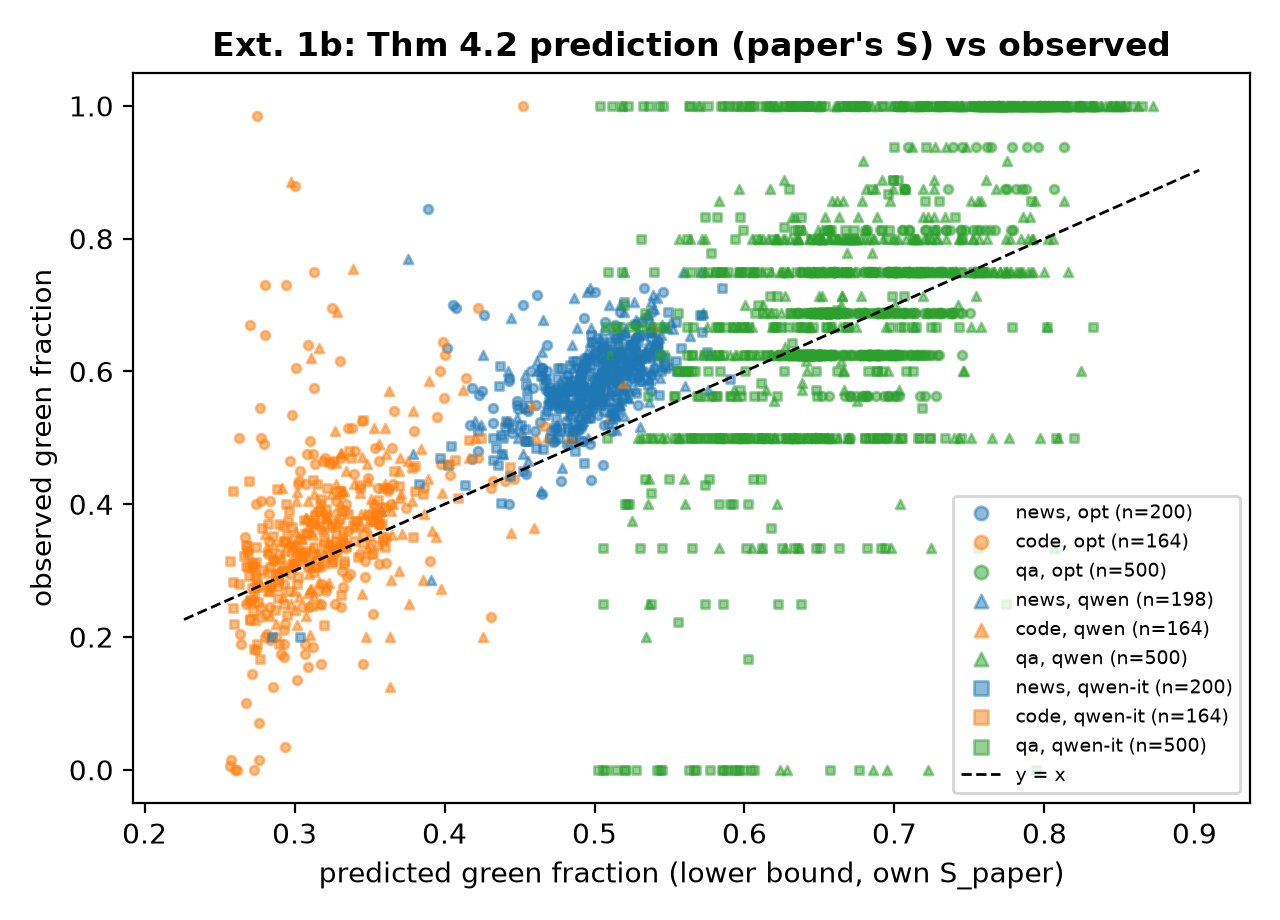

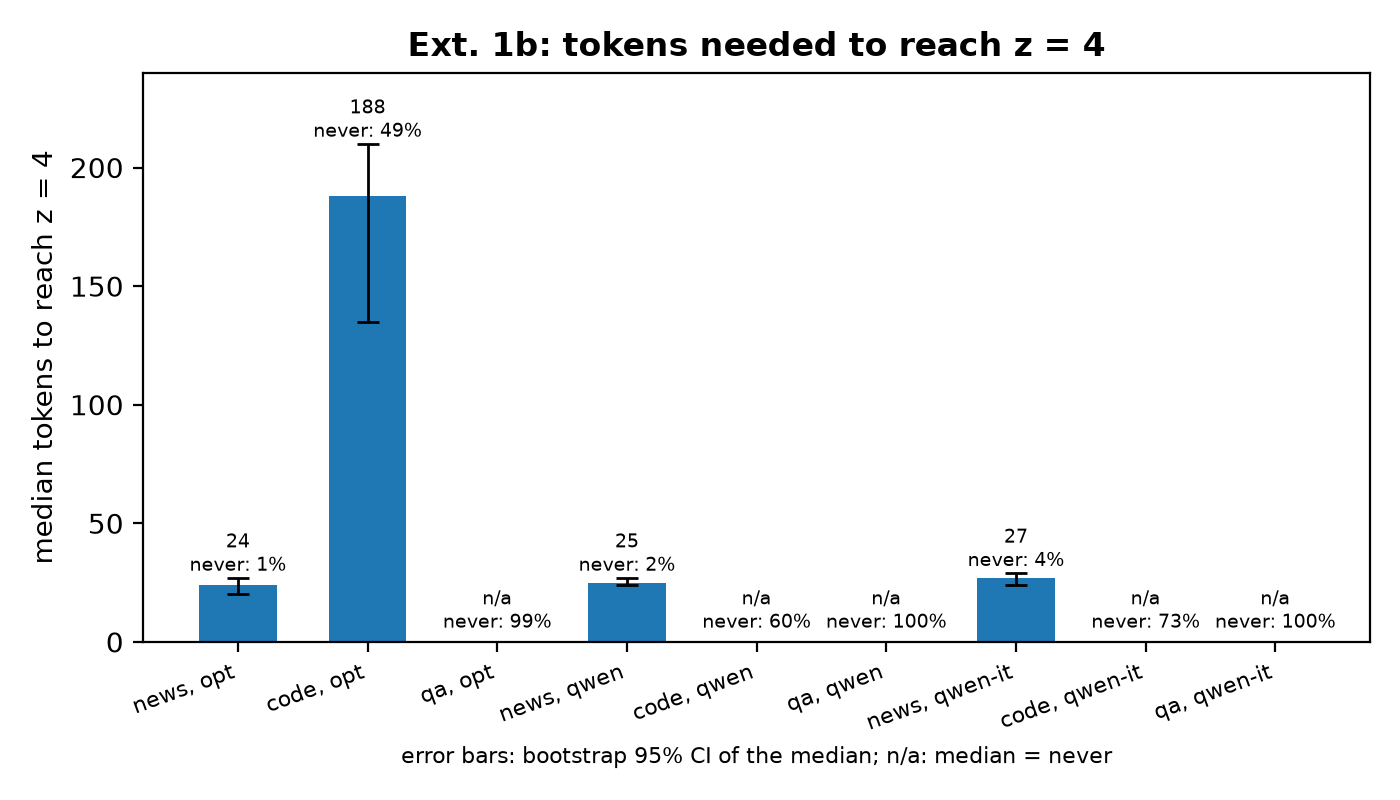

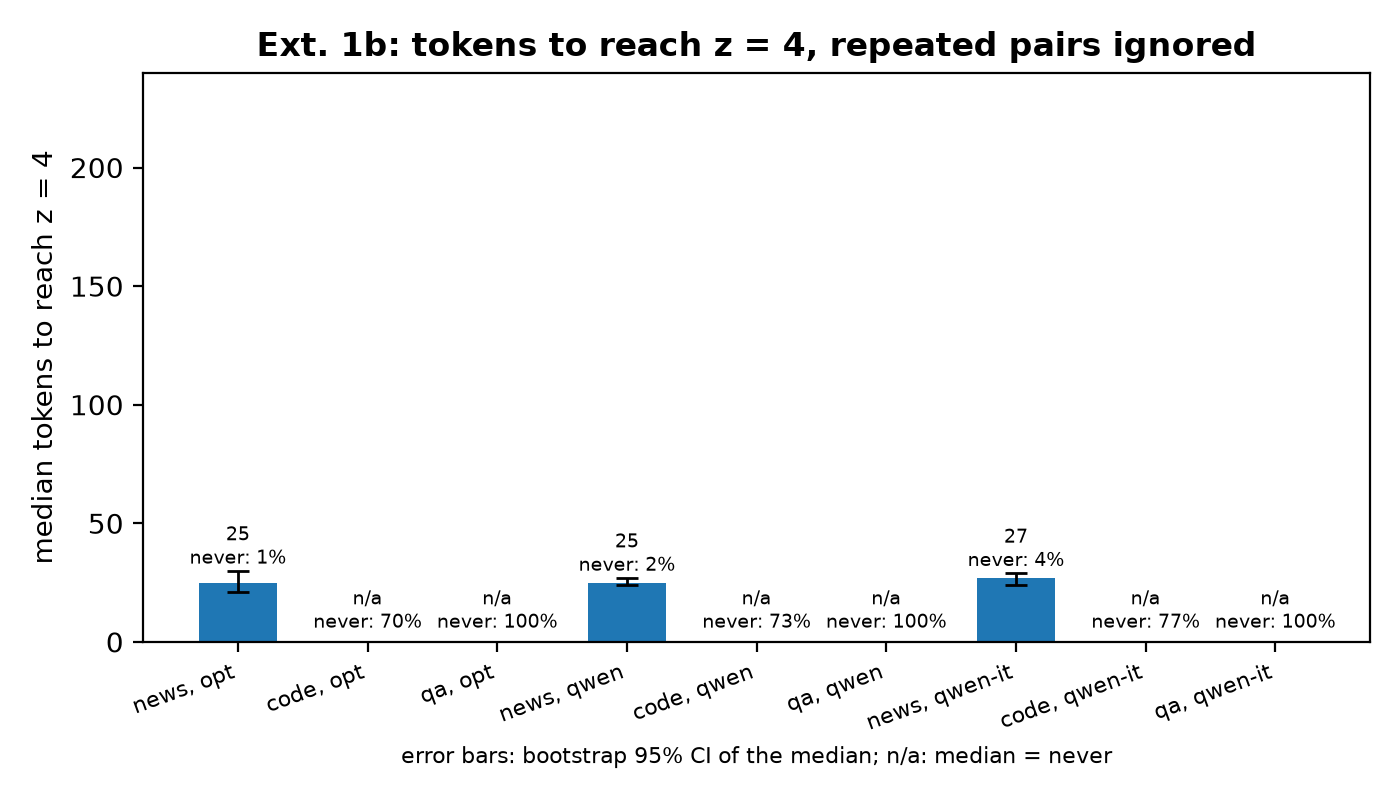

In [21]:
show("ext1b_z_vs_entropy.png", "ext1b_z_vs_entropy_repeats.png", "ext1b_theory_vs_observed.png", "ext1b_theory_vs_observed_paper.png", "ext1b_tokens_to_detect.png", "ext1b_tokens_to_detect_norep.png")

In [22]:
# 1c: per-token spike entropy (sampled distribution), base vs instruct
hist = {}
for dom in ("news", "code"):
    for m, label in (("qwen", "base"), ("qwen-it", "instruct")):
        if (dom, m) in cells:
            hist[f"{label}, {dom}"] = np.concatenate([r["S_sampled"] for r in cells[(dom, m)]])
if hist:
    PL.entropy_hist(hist, "ext1c_entropy_hist.png", "Ext. 1c: Qwen2.5-1.5B base vs instruct (γ = 0.25, δ = 2)",
                    "per-token spike entropy on the sampled distribution")

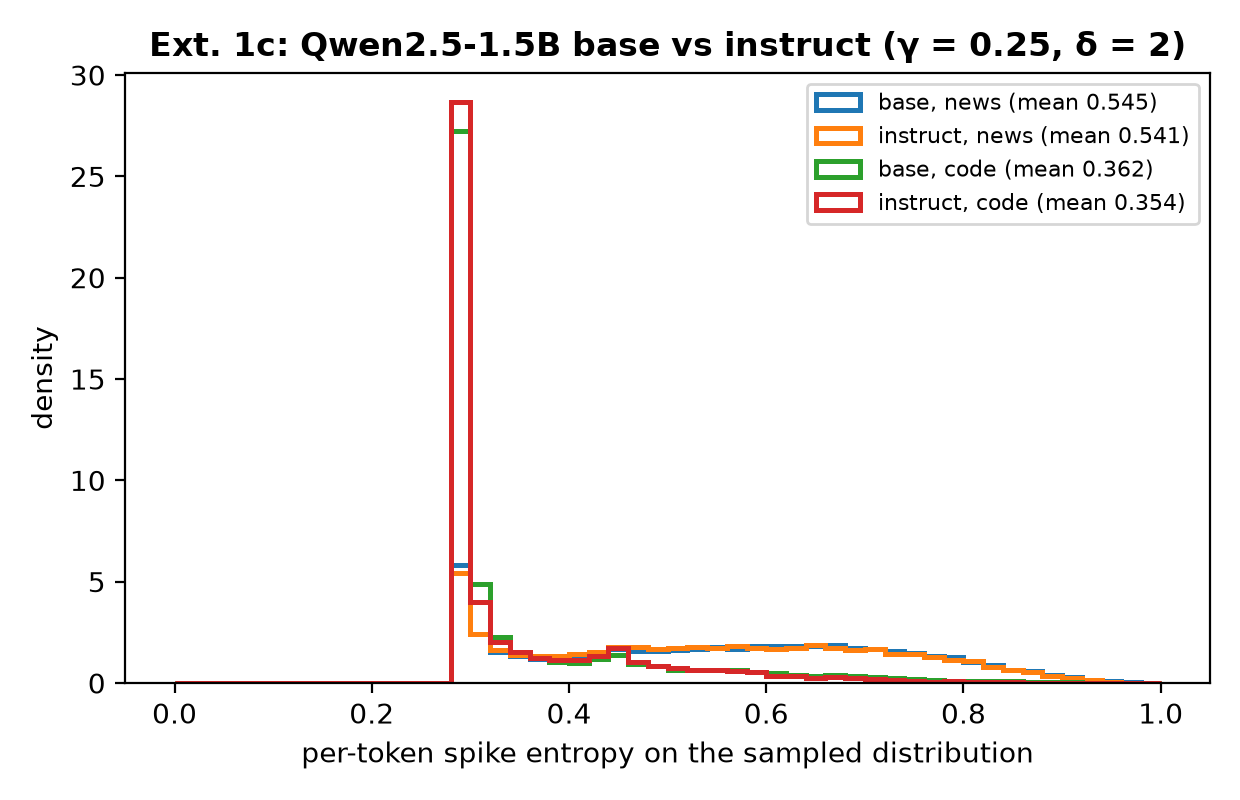

In [23]:
show("ext1c_entropy_hist.png")

---
##### Extension 2
A 2026 attacker: modern paraphrase vs T5 on the same texts, and copy-paste dilution.

In [24]:
e2 = []
if len(scored):
    reenc = scored[(scored.attack == "none") & (scored.src == "wm")]
    for (att, lvl), grp in scored[scored.src.isin(["wm", "human"])].groupby(["attack", "level"]):
        pos, neg = grp[grp.src == "wm"], grp[grp.src == "human"]
        if not len(pos) or not len(neg):
            continue
        tpr1, thr = S.tpr_at_fpr(pos.z.values, neg.z.values, 0.01)
        e2.append(dict(attack=att, level=lvl, n_pos=len(pos), n_neg=len(neg), TPR_z4=(pos.z > 4).mean(),
                       FPR_z4=(neg.z > 4).mean(), TPR_1pctFPR=tpr1, thr_1pctFPR=thr, AUC=S.auc(pos.z.values, neg.z.values),
                       meaning_kept=pos.cos.mean(), meaning_kept_human=neg.cos.mean(), tokens_changed=pos.edit.mean(),
                       T_mean=pos["T"].mean(), PPL_mean=pos.ppl.mean(), z_mean=pos.z.mean(), z_mean_human=neg.z.mean(),
                       green_frac=np.mean([S.green(r, 0.5, VO).mean() if len(r) else np.nan for r in pos.ranks]),
                       TPR_z4_lo=S.wilson_of(pos.z > 4)[0], TPR_z4_hi=S.wilson_of(pos.z > 4)[1],
                       TPR_1pct_lo=S.wilson_of(pos.z > thr)[0], TPR_1pct_hi=S.wilson_of(pos.z > thr)[1],
                       FPR_z4_hi=S.wilson_of(neg.z > 4)[1],
                       meaning_lo=pos.cos.mean() - 1.96 * pos.cos.std() / np.sqrt(len(pos)),
                       meaning_hi=pos.cos.mean() + 1.96 * pos.cos.std() / np.sqrt(len(pos))))
e2 = save("ext2a_attacks", pd.DataFrame(e2)) if e2 else pd.DataFrame()
display(e2)
if len(e2):
    name = {"none": "no attack", "t5": "T5, multi-word fills", "t5w": "T5, single-word (paper's rule)", "para": "Qwen2.5-1.5B paraphrase"}
    order = {"light": 1, "medium": 2, "full": 3}
    e2s = e2.assign(o=[order.get(str(l), l) for l in e2.level]).sort_values(["attack", "o"], key=lambda c: c.astype(str) if c.name == "attack" else c.astype(float))
    full = e2s[e2s.n_neg >= 100]     # 1% FPR needs >= 100 attacked human texts (single-word T5 has 28)
    pts = [(name[r.attack], r.level if r.attack != "none" else "", r.meaning_kept, r.TPR_1pctFPR, (r.TPR_1pct_lo, r.TPR_1pct_hi))
           for r in full.itertuples()]
    PL.removal_frontier(pts, "ext2a_removal_frontier.png", "Ext. 2a: the price of removing the watermark",
                        f"n = {full.n_pos.min()}-{full.n_pos.max()} watermarked + as many attacked human texts per point")
    pts4 = [(name[r.attack], r.level if r.attack != "none" else "", r.meaning_kept, r.TPR_z4, (r.TPR_z4_lo, r.TPR_z4_hi))
            for r in e2s.itertuples()]
    PL.removal_frontier(pts4, "ext2a_removal_frontier_z4.png", "Ext. 2a: removal at the fixed threshold z = 4",
                        "n = 100-200 watermarked texts per point", ylabel="TPR at z = 4 (no calibration needed)")

,attack,level,n_pos,n_neg,TPR_z4,FPR_z4,TPR_1pctFPR,thr_1pctFPR,AUC,meaning_kept,meaning_kept_human,tokens_changed,T_mean,PPL_mean,z_mean,z_mean_human,green_frac,TPR_z4_lo,TPR_z4_hi,TPR_1pct_lo,TPR_1pct_hi,FPR_z4_hi,meaning_lo,meaning_hi
0,none,0,200,200,1.000,0.000,1.000,2.263,1.000,1.000,1.000,4.750e-04,199.945,6.553,8.253,-0.165,0.792,0.981,1.000,0.981,1.000,0.019,1.000,1.000
1,para,full,200,200,0.015,0.000,0.100,2.631,0.705,0.837,0.863,8.563e-01,179.710,20.551,0.822,-0.105,0.531,0.005,0.043,0.066,0.149,0.019,0.822,0.852
2,para,light,200,200,0.220,0.000,0.435,2.437,0.881,0.850,0.844,6.502e-01,141.445,30.129,2.408,-0.096,0.605,0.168,0.282,0.368,0.504,0.019,0.828,0.872
3,para,medium,200,200,0.035,0.000,0.205,2.212,0.773,0.848,0.864,8.094e-01,176.960,21.149,1.190,-0.155,0.545,0.017,0.070,0.155,0.266,0.019,0.834,0.862
4,t5,0.1,200,200,0.955,0.005,1.000,2.574,1.000,0.951,0.950,2.169e-01,231.595,8.053,6.651,-0.061,0.718,0.917,0.976,0.981,1.000,0.028,0.947,0.955
5,t5,0.3,200,200,0.495,0.000,0.925,2.134,0.991,0.881,0.871,6.465e-01,294.690,9.918,4.293,-0.087,0.624,0.426,0.564,0.880,0.954,0.019,0.874,0.888
6,t5w,0.1,100,100,0.990,0.000,0.990,3.902,1.000,0.953,0.955,1.128e-01,200.770,9.243,6.300,-0.088,0.722,0.946,0.998,0.946,0.998,0.037,0.946,0.960
7,t5w,0.3,100,100,0.240,0.000,0.810,2.376,0.995,0.856,0.872,3.416e-01,202.280,16.040,3.417,-0.101,0.620,0.167,0.332,0.722,0.875,0.037,0.843,0.868
8,t5w,0.5,100,100,0.020,0.000,0.110,2.467,0.824,0.774,0.790,5.703e-01,205.510,24.792,1.367,-0.010,0.548,0.006,0.070,0.063,0.186,0.037,0.757,0.791
9,t5w,0.7,100,100,0.010,0.000,0.010,3.236,0.607,0.719,0.727,7.489e-01,209.870,33.473,0.404,0.029,0.514,0.002,0.054,0.002,0.054,0.037,0.700,0.738


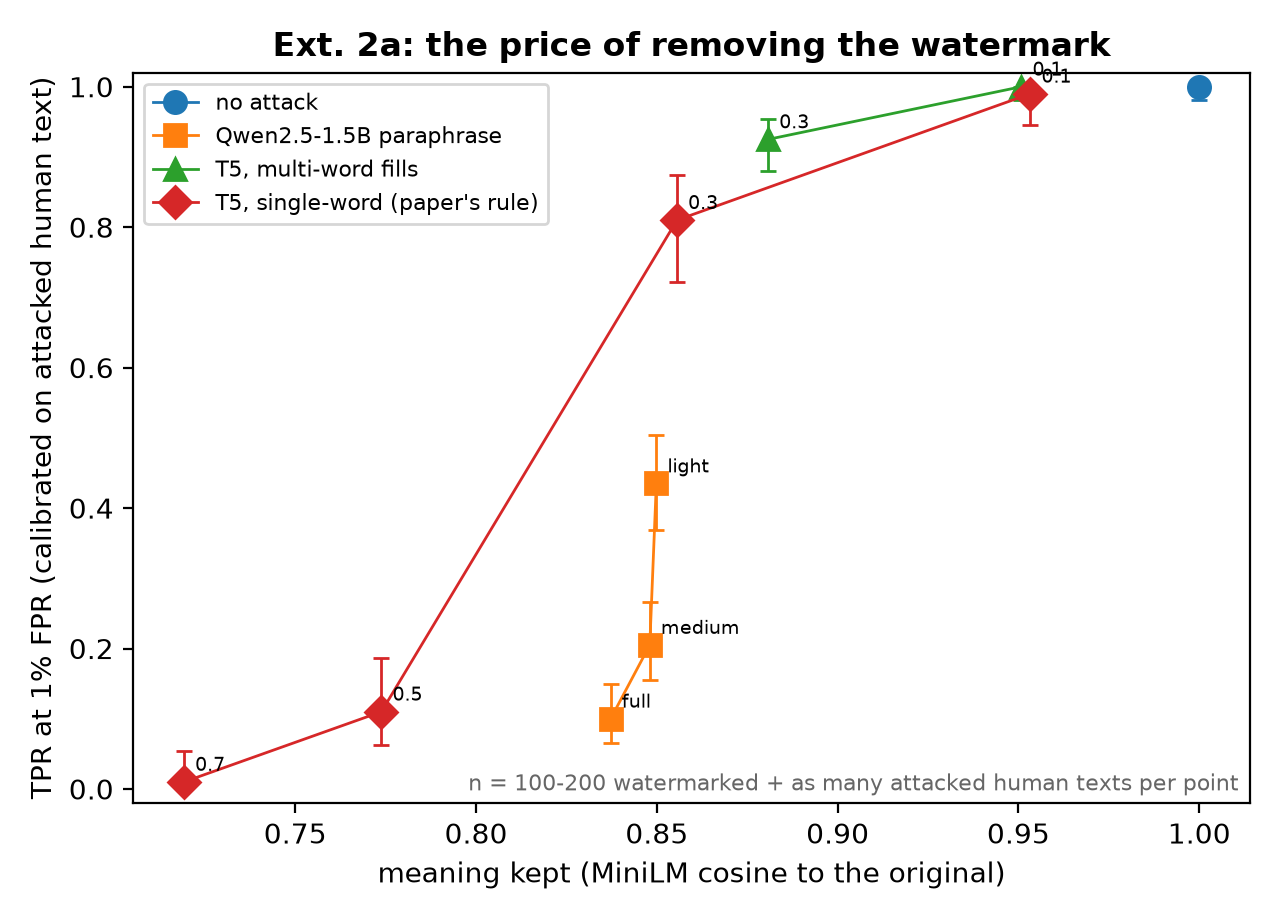

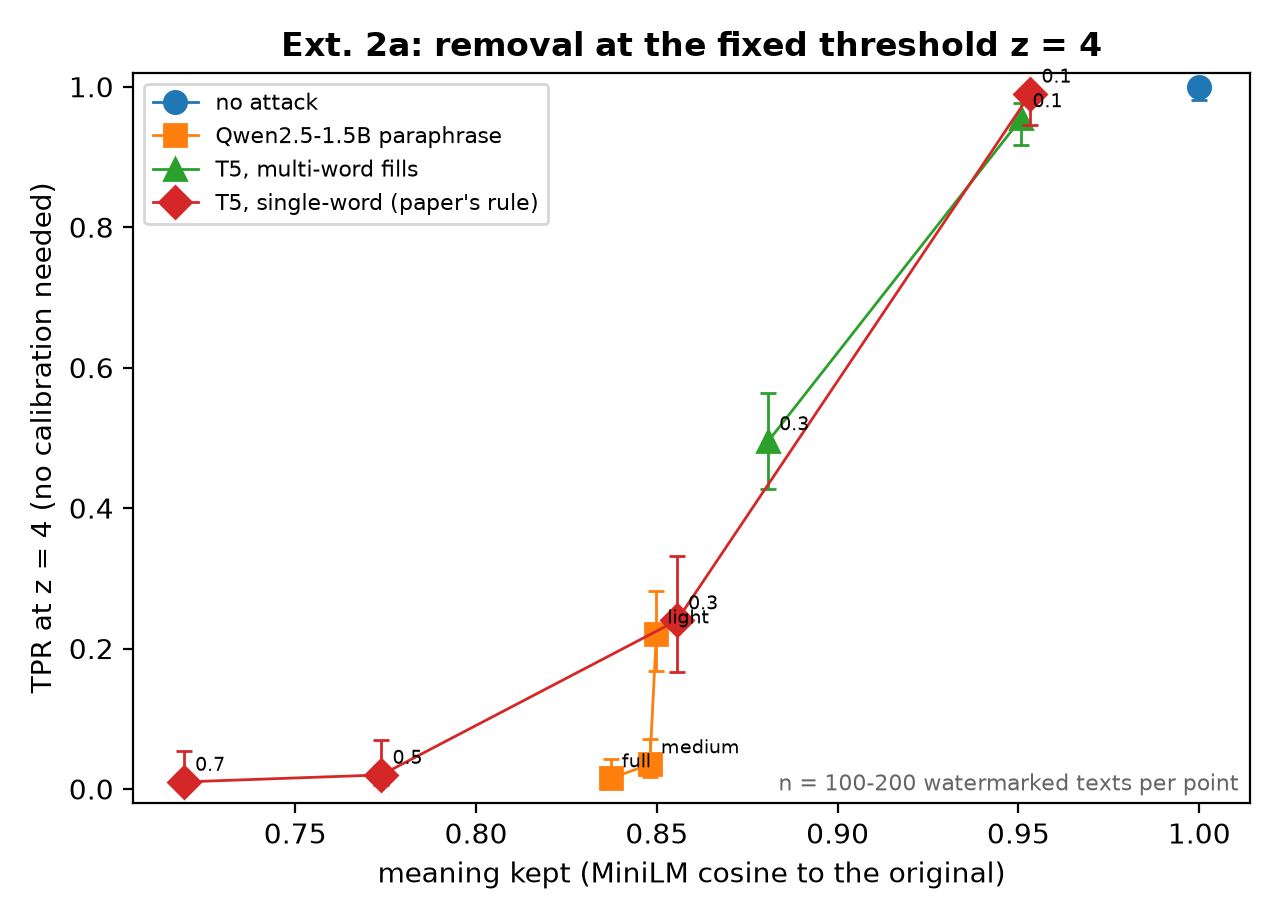

In [25]:
show("ext2a_removal_frontier.png", "ext2a_removal_frontier_z4.png")

In [26]:
dpath = C.raw_path("dilution", "docs")
if os.path.exists(dpath):
    docs = pd.DataFrame(C.read_jsonl(dpath))
    neg = docs[docs.kind == "human"]
    rows2b = []
    thr_z = S.tpr_at_fpr([0], neg.z.values)[1]
    thr_w = S.tpr_at_fpr([0], neg.winmax.values)[1]
    for share, grp in docs[docs.kind == "mixed"].groupby("share"):
        rows2b.append(dict(share=share, n=len(grp), TPR_full_z=S.tpr_at_fpr(grp.z.values, neg.z.values)[0],
                           TPR_winmax=S.tpr_at_fpr(grp.winmax.values, neg.winmax.values)[0],
                           TPR_full_z_at_4=(grp.z > 4).mean(), z_mean=grp.z.mean(), winmax_mean=grp.winmax.mean(),
                           full_z_lo=S.wilson_of(grp.z > thr_z)[0], full_z_hi=S.wilson_of(grp.z > thr_z)[1],
                           winmax_lo=S.wilson_of(grp.winmax > thr_w)[0], winmax_hi=S.wilson_of(grp.winmax > thr_w)[1]))
    e2b = save("ext2b_dilution", pd.DataFrame(rows2b))
    save_json("ext2b_thresholds", dict(n_neg=len(neg), thr_full_z=thr_z, thr_winmax=thr_w, neg_z_mean=neg.z.mean(),
                                       neg_z_sd=neg.z.std(), neg_winmax_mean=neg.winmax.mean()))
    display(e2b)
    print(f"1% FPR thresholds from {len(neg)} human-only documents: full-text z > {thr_z:.2f}, WinMax > {thr_w:.2f}")
    PL.dilution(list(e2b.share), {"full-text z": list(e2b.TPR_full_z), "WinMax (sliding window)": list(e2b.TPR_winmax)},
                "ext2b_dilution.png", "Ext. 2b: watermarked span inside human text",
                f"n = {e2b.n.min()} docs per share, {len(neg)} human docs")

,share,n,TPR_full_z,TPR_winmax,TPR_full_z_at_4,z_mean,winmax_mean,full_z_lo,full_z_hi,winmax_lo,winmax_hi
0,0.10,200,0.115,0.865,0.010,1.028,4.984,0.078,0.167,0.811,0.906
1,0.25,200,0.815,0.995,0.285,3.299,7.358,0.755,0.863,0.972,0.999
2,0.50,200,1.000,1.000,0.975,6.858,10.254,0.981,1.000,0.981,1.000


1% FPR thresholds from 1000 human-only documents: full-text z > 2.20, WinMax > 4.02


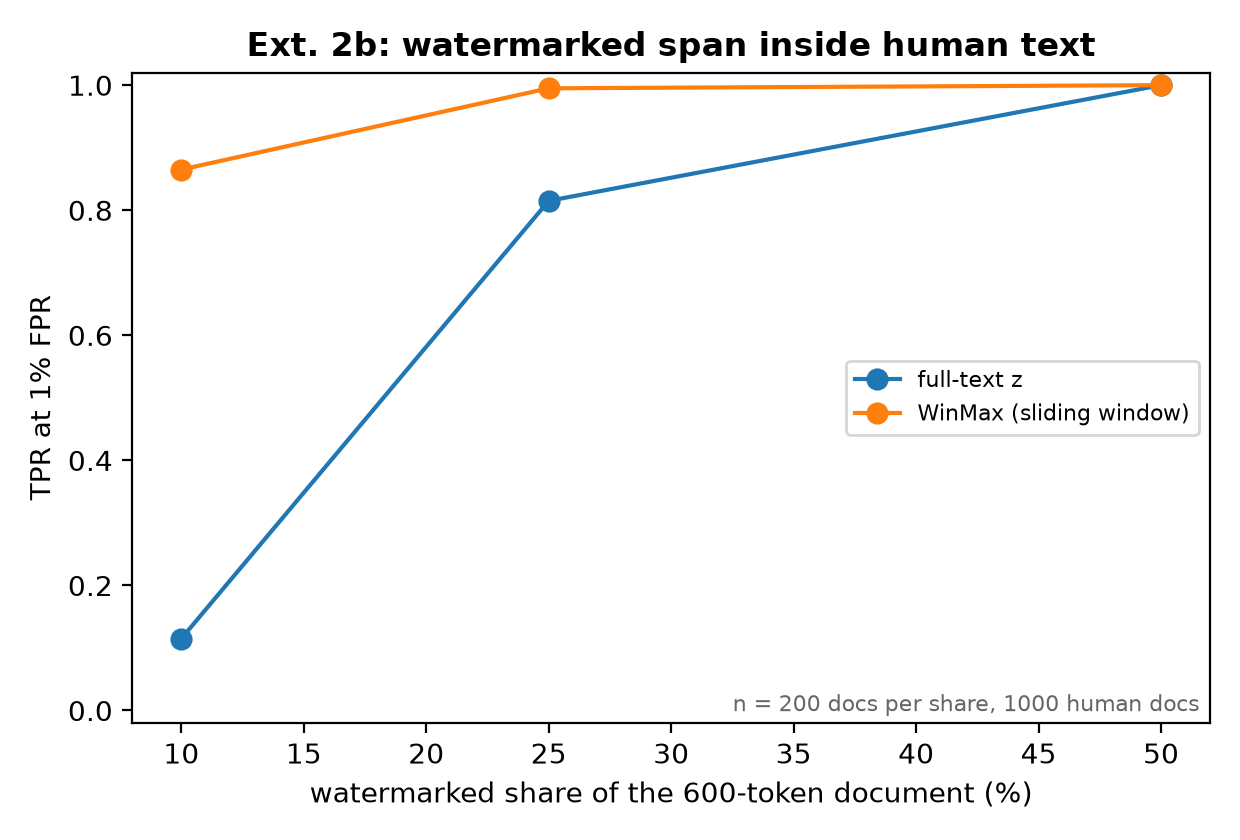

In [27]:
show("ext2b_dilution.png")